# Code de Correction MAR par rapport a v4 SNOW-CCI puis tendance ligne de neige en utlisant la formule ligne de neige modifie

1.On commence avec la correction de MAR de maniere mensuelle et avec un Delta qunatile mapping

En fin de partie tentative d'inversion de la formule LA23 (pas satisfaisant)

2.Creation de tendance MAR de la hauteur ligne de neige sur l'ensemble du domaine temporel

Dans ce notebook on utilse une version Gap-Filled de la V4 SNOW-CCI ou l'on a une disponibilite complete en donnees. Ainsi que MAR  force par la reanalyse ERA5, cesst le cas pour les 2 autres notebook de correction de ce stage.

## IMPORTANT

#### Une chose a savoir pour la periode de calibration il faut ouvrir sur 2016-2019 pour faire la suite avec la cross validation , mais si lobjectif et daller voir la partie ligne de neige (2) alors il faut ouvrir sur 2016 2021 et ne pas faire tourner les lignes de verifications (donc sarreter apres la definiton des fonctions et la case de leur application) et repartir a la partie 2 

In [1]:
import warnings
warnings.filterwarnings('ignore')
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import pandas as pd
import sys
import os 
import calendar
from scipy.interpolate import interp1d
import scipy.stats as stats
from matplotlib.lines import Line2D
sys.path.append('/home/mougina/mesnotebooks/utils')
from config import ds_grid, alps_ice, lon, lat, H, alps, get_season 

In [2]:
## topo v4 
lat1, lat2, lon1, lon2 = 43, 48, 5, 17
ds_topo = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/mougina/GMTED2010_15n015_0050deg.nc').rename(
    {'latitude': 'lat', 'longitude': 'lon'}
)
dsi_topo = ds_topo.sel(lat=slice(lat1, lat2), lon=slice(lon1, lon2))
## grille MAR
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")

Dimensions de la topo Alpes : (2400, 6240)
Rugosité Min : -11.0
Rugosité Max : 4712.0


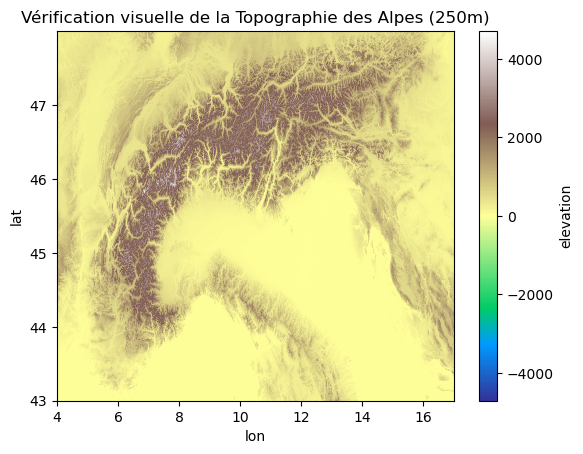

In [3]:

ds_topo_HR = xr.open_dataset("/bettik/PROJECTS/pr-regional-climate/mougina/gmted_topo_alpes_250m.nc")
topo_mondiale_HR = ds_topo_HR['elevation']
lon1, lon2, lat1, lat2 = 4, 17, 43, 48
vrai_topo_alpes_HR = topo_mondiale_HR.sel(
    lon=slice(min(lon1, lon2), max(lon1, lon2)), 
    lat=slice(max(lat1, lat2), min(lat1, lat2))
)
if vrai_topo_alpes_HR.sizes['lat'] == 0:
    vrai_topo_alpes_HR = topo_mondiale_HR.sel(
        lon=slice(min(lon1, lon2), max(lon1, lon2)), 
        lat=slice(min(lat1, lat2), max(lat1, lat2))
    )
print("Dimensions de la topo Alpes :", vrai_topo_alpes_HR.shape)
print("Rugosité Min :", float(vrai_topo_alpes_HR.min()))
print("Rugosité Max :", float(vrai_topo_alpes_HR.max()))

vrai_topo_alpes_HR.plot(cmap='terrain')
plt.title("Vérification visuelle de la Topographie des Alpes (250m)")
plt.show()

In [4]:
# ecart type pour LA23
facteur_lon = vrai_topo_alpes_HR.shape[1] // ds_grid.LON.shape[1]
facteur_lat = vrai_topo_alpes_HR.shape[0] // ds_grid.LON.shape[0]


sigma_topo_brut = vrai_topo_alpes_HR.coarsen(lon=facteur_lon, lat=facteur_lat, boundary='trim').std()
sigma_topo_aligned = sigma_topo_brut.interp(lon=ds_grid.LON[0, :], lat=ds_grid.LAT[:, 0], method='nearest')
topo_numpy = sigma_topo_aligned.reindex_like(ds_grid, method='nearest').values


In [5]:
file_v2 = '/home/mougina/mes_analyses_neige/Alpine_snow.nc'
ds_v2 = xr.open_dataset(file_v2)

scfg_raw = ds_v2['scfg_interp'].where((ds_v2['scfg_interp'] >= 0) & (ds_v2['scfg_interp'] <= 100))

is_water = ds_v2['mask_water'].fillna(0) == 210
is_ice = ds_v2['mask_ice'].fillna(0) == 215

In [6]:
#base pour la formule de NY07 et LA23

z0g = 0.01         
rho_new = 50.0     ## les donnees so nt celle utilise dans l'article de Lalande et al. 2023
m = 1.0
beta = 3*10**-6
n = 3.0


In [7]:
def get_seasonal_mean(data, season_suffix, years):
    liste = []
    for yr in years:
        target = f"{yr}_{season_suffix}"
        s = data.where(data.season == target).mean(dim='time')
        liste.append(s)
    return xr.concat(liste, dim='year').mean(dim='year')

In [8]:
### fonction calcul du rho moyen 
def calc_rho_mean(ds_rho, SD):
    levels_da = xr.DataArray(
        [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0, 3.0, 5.0, 10.0, 15.0],
        coords=[ds_rho['outlay']], dims=['outlay']
    )
    
    mask = xr.concat([
        xr.ones_like(ds_rho['RO1'].isel(outlay=[0])),
        (ds_rho['RO1'].diff('outlay') != 0)
    ], dim='outlay')

    # Poids corrigé : le dernier nœud actif s'arrête à SD et non au niveau suivant
    levels_next = levels_da.shift(outlay=-1, fill_value=15.0)
    dz_corrige  = (np.minimum(levels_next, SD) - levels_da.shift(outlay=1, fill_value=0.0)) / 2
    dz_corrige  = dz_corrige.clip(min=0)

    return (ds_rho['RO1'].where(mask)
            .weighted(dz_corrige.where(mask).fillna(0))
            .mean(dim='outlay'))

### 1ere Partie 

In [9]:
years_train = [2016, 2017, 2018, 2019,2020,2021] ## ouverture des 5 ans ici pour ligne de neige 
lat1, lat2, lon1, lon2 =  43, 48, 5, 17  # Alpes

In [10]:
list_mar = []
list_v4= []
lon_1d = ds_grid.LON[0, :] 
lat_1d = ds_grid.LAT[:, 0] 
for i, yr in enumerate(years_train):
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")  
    SD = ds_m['ZN3']
    rho_snow = calc_rho_mean(ds_rho, SD)
    topo_numpy = sigma_topo_aligned.fillna(0).values
    denominateur = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    denominateur_safe = denominateur.where(denominateur > 0, other=1e-10)
    scf_mar = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe) * 100)
    list_mar.append(scf_mar)
    
    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs:
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] >= 0, np.nan)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] <= 100, np.nan)
    v4_regrid = ds_v['scfg'].interp(
        lon=ds_grid.LON, lat=ds_grid.LAT,
        method="linear", kwargs={'fill_value': np.nan}
    )
    list_v4.append(v4_regrid)

all_mar_train = xr.concat(list_mar, dim='time')
all_v4_train  = xr.concat(list_v4, dim='time')

all_mar_train = all_mar_train.sel(time=all_v4_train.time, method="nearest")
# Masque une seule fois
alps_ice_da = xr.DataArray(alps_ice, dims=['y', 'x'])
all_mar_train = all_mar_train.where(alps_ice_da)

clim_v4 = all_v4_train.groupby('time.month').mean(dim='time')
clim_mar = all_mar_train.groupby('time.month').mean(dim='time')



biais_pixel_mensuel = clim_mar - clim_v4
print("biais shape:", biais_pixel_mensuel.shape)



biais shape: (12, 126, 201)


les fonctions utiles

In [11]:
# correction par biais moyen mensuel 
def corriger_biais_pixel(all_mar_train, biais_pixel_mensuel):
    liste_corriges = []
        
    for m in range(1, 13):
        mar_jours = all_mar_train.where(all_mar_train['time.month'] == m, drop=True)
        if mar_jours.sizes['time'] == 0:
            continue
                
        m_prev = 12 if m == 1 else m - 1
        m_next = 1  if m == 12 else m + 1
                
        
        biais_prev = biais_pixel_mensuel.sel(month=m_prev)
        biais_curr = biais_pixel_mensuel.sel(month=m)
        biais_next = biais_pixel_mensuel.sel(month=m_next)
                
        n_jours = mar_jours.sizes['time']
                
        for t in range(n_jours):
            pos = t / (n_jours - 1) if n_jours > 1 else 0.5
            
            if pos < 0.5:
                alpha = pos * 2  
                biais_t = (1 - alpha) * biais_prev + alpha * biais_curr
            else:
                alpha = (pos - 0.5) * 2  
                biais_t = (1 - alpha) * biais_curr + alpha * biais_next
                        
            jour_corrige = (mar_jours.isel(time=t) - biais_t).clip(0, 100)
            liste_corriges.append(jour_corrige)
        
    return xr.concat(liste_corriges, dim='time').sortby('time')

all_mar_corrige= corriger_biais_pixel(all_mar_train, biais_pixel_mensuel)

In [12]:
from scipy.stats import rv_histogram as pystat

def qdm_calibrer(all_mar_train, all_v4_train, n_quantiles=50):
    """
    Calibre la distribution V4 de référence (équivalent de temp_saf_dist du prof)
    et la distribution MAR sur la période de référence (équivalent de temp_ssp_dist)
    """
    alps_ice_da = xr.DataArray(alps_ice, dims=all_mar_train.dims[1:])
    alps_mask = alps_ice_da.values
    _, nlat, nlon = all_mar_train.shape
    quantiles_ref = {}
    
    for m in range(1, 13):
        print(f"Calibration mois {m}...")
        mar_mois = all_mar_train.where(all_mar_train['time.month'] == m, drop=True)
        v4_mois  = all_v4_train.where(all_v4_train['time.month'] == m, drop=True)
        if mar_mois.sizes['time'] == 0:
            continue
        
        mar_vals = mar_mois.values
        v4_vals  = v4_mois.values
        mar_dist_mois = np.empty((nlat, nlon), dtype=object)
        v4_dist_mois  = np.empty((nlat, nlon), dtype=object)
        np.random.seed(42)
        
        for i in range(nlat):
            for j in range(nlon):
                if not alps_mask[i, j]:
                    continue
                mar_px    = mar_vals[:, i, j]
                v4_px     = v4_vals[:, i, j]
                mar_valid = mar_px[~np.isnan(mar_px)]
                v4_valid  = v4_px[~np.isnan(v4_px)]
                if len(mar_valid) < 10 or len(v4_valid) < 10:
                    continue
                mar_valid = np.where(mar_valid == 0,
                    np.random.uniform(0, 1e-5, mar_valid.shape), mar_valid)
                try:
                    mar_dist_mois[i, j] = pystat(
                        np.histogram(mar_valid, bins=50, range=(0, 100)))
                    v4_dist_mois[i, j] = pystat(
                        np.histogram(v4_valid, bins=50, range=(0, 100)))
                except Exception:
                    continue
        
        quantiles_ref[m] = {
            'mar_dist': mar_dist_mois,  # équivalent temp_ssp_dist
            'v4_dist' : v4_dist_mois    # équivalent temp_saf_dist
        }
    return quantiles_ref


def qdm_appliquer(all_mar, quantiles_ref, window=20, n_quantiles=50):
    """
    Applique le QDM avec CDF rolling 
    Vincent : 
    temp_rolling_cdf[m][y] = distribution glissante ±20 ans autour de l'année y
    temp_cor = temp + saf_dist.ppf(rolling_cdf[y].cdf(temp)) - ssp_dist.ppf(rolling_cdf[y].cdf(temp))
    
    Adapté SCF :
    scf_cor = scf + v4_dist.ppf(roll_cdf[y].cdf(scf)) - mar_dist_ref.ppf(roll_cdf[y].cdf(scf))
    """
    alps_ice_da = xr.DataArray(alps_ice, dims=all_mar.dims[1:])
    alps_mask = alps_ice_da.values
    liste_corriges = []
    
    for m in range(1, 13):
        print(f"Application mois {m}...")
        mar_mois = all_mar.where(all_mar['time.month'] == m, drop=True)
        if mar_mois.sizes['time'] == 0:
            continue
        
        v4_dist_ref = quantiles_ref[m]['v4_dist']
        mar_vals    = mar_mois.values
        mar_years   = mar_mois.time.dt.year.values
        n_jours, nlat, nlon = mar_vals.shape
        mar_corrige = np.full_like(mar_vals, np.nan)
        np.random.seed(42)
        
        for yr in np.unique(mar_years):
            idx_yr = np.where(mar_years == yr)[0]
    
            mar_rolling = all_mar.where(
                (all_mar['time.month'] == m) &
                (all_mar.time.dt.year >= yr - window) &
                (all_mar.time.dt.year <= yr + window),
                drop=True
            )
            
            for i in range(nlat):
                for j in range(nlon):
                    if not alps_mask[i, j]:
                        continue
                    
                    v4_dist = v4_dist_ref[i, j]
                    if v4_dist is None:
                        mar_corrige[idx_yr, i, j] = mar_vals[idx_yr, i, j]
                        continue
                    
                    mar_roll_px = mar_rolling.values[:, i, j]
                    mar_roll_valid = mar_roll_px[~np.isnan(mar_roll_px)]
                    if len(mar_roll_valid) < 10:
                        mar_corrige[idx_yr, i, j] = mar_vals[idx_yr, i, j]
                        continue
                    
                    mar_roll_valid = np.where(mar_roll_valid == 0,
                        np.random.uniform(0, 1e-5, mar_roll_valid.shape), mar_roll_valid)
                    
                    try:
                        mar_roll_dist = pystat(np.histogram(
                            mar_roll_valid, bins=50, range=(0, 100)))
                    except Exception:
                        mar_corrige[idx_yr, i, j] = mar_vals[idx_yr, i, j]
                        continue
                    
                    mar_px = mar_vals[idx_yr, i, j].copy()
                    mar_px = np.where(mar_px == 0,
                        np.random.uniform(0, 1e-5, mar_px.shape), mar_px)
                    
                    cdf_vals = np.clip(mar_roll_dist.cdf(mar_px), 1e-6, 1-1e-6)
                    mar_corrige[idx_yr, i, j] = np.clip(
                        mar_px + v4_dist.ppf(cdf_vals) - mar_roll_dist.ppf(cdf_vals),
                        0, 100)
        
        mar_corrige_da = xr.DataArray(
            mar_corrige, coords=mar_mois.coords, dims=mar_mois.dims
        ).clip(0, 100)
        liste_corriges.append(mar_corrige_da)
    
    return xr.concat(liste_corriges, dim='time').sortby('time')

In [13]:
ds_quantiles_ref = qdm_calibrer(all_mar_train, all_v4_train)
all_mar_corr_train = corriger_biais_pixel(all_mar_train, biais_pixel_mensuel)
all_mar_qdm_train = qdm_appliquer(all_mar_train, ds_quantiles_ref)

Calibration mois 1...
Calibration mois 2...
Calibration mois 3...
Calibration mois 4...
Calibration mois 5...
Calibration mois 6...
Calibration mois 7...
Calibration mois 8...
Calibration mois 9...
Calibration mois 10...
Calibration mois 11...
Calibration mois 12...
Application mois 1...
Application mois 2...
Application mois 3...
Application mois 4...
Application mois 5...
Application mois 6...
Application mois 7...
Application mois 8...
Application mois 9...
Application mois 10...
Application mois 11...
Application mois 12...


### Verification de l'entrainement de notre correction MAR 2016-2019

In [16]:

alps_ice_da = xr.DataArray(alps_ice, dims=['y', 'x'])

v4_numpy      = all_v4_train.where(alps_ice_da).values.ravel()
mar_numpy     = all_mar_train.where(alps_ice_da).values.ravel()
qdm_px_numpy     = all_mar_qdm_train.where(alps_ice_da).values.ravel()
corrige_numpy = all_mar_corr_train.where(alps_ice_da).values.ravel()

# Enlever les NaN
mask_valid = (~np.isnan(v4_numpy) & ~np.isnan(mar_numpy)& ~np.isnan(corrige_numpy) & ~np.isnan(qdm_px_numpy))

bias_brut    = np.nanmean(mar_numpy[mask_valid] - v4_numpy[mask_valid])
bias_corrige = np.nanmean(corrige_numpy[mask_valid] - v4_numpy[mask_valid])
bias_qdm_px     = np.nanmean(qdm_px_numpy[mask_valid] - v4_numpy[mask_valid])

print(f"Biais Moyen sans correction : {bias_brut:.3f} %")
print(f"Biais Moyen correction additive : {bias_corrige:.3f} %")
print(f"Biais Moyen QDM pixel par pixel : {bias_qdm_px:.3f} %")

Biais Moyen sans correction : -6.099 %
Biais Moyen correction additive : -0.737 %
Biais Moyen QDM pixel par pixel : -3.785 %


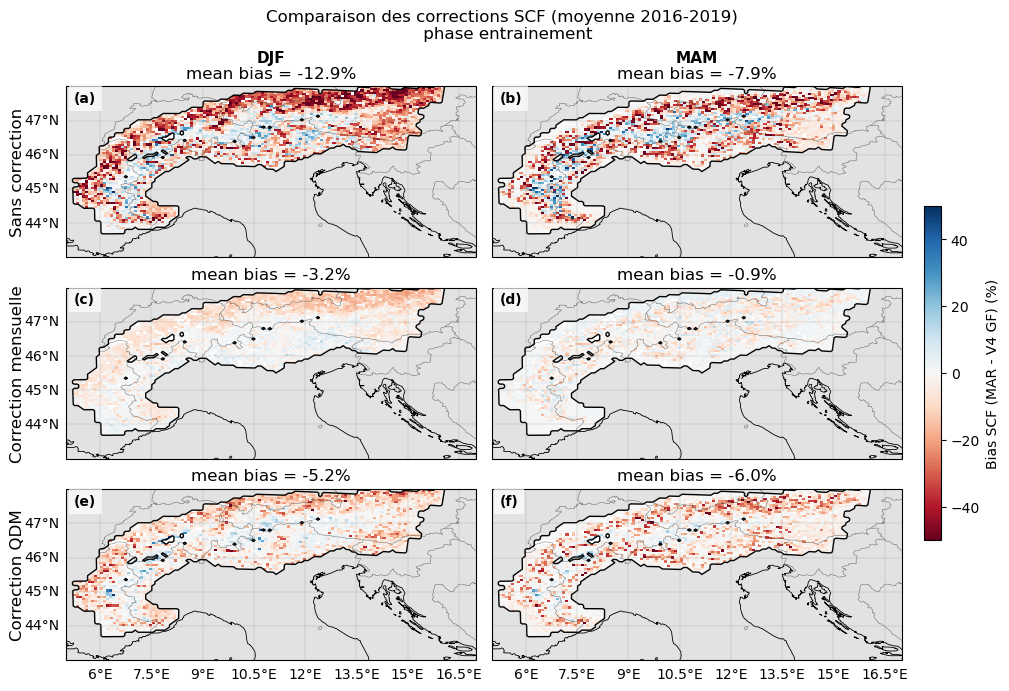

In [17]:
time_pd_v4 = all_v4_train.time.to_index()
season_labels = [get_season(t) for t in time_pd_v4]
all_mar= all_mar_train.assign_coords(season=('time', season_labels))
all_mar_qdm_px= all_mar_qdm_train.assign_coords(season=('time', season_labels))
all_mar_corrige= all_mar_corr_train.assign_coords(season=('time', season_labels))
all_v4 = all_v4_train.assign_coords(season=('time', season_labels))



winter_brut   = get_seasonal_mean(all_mar, 'DJF', years_train)
spring_brut   = get_seasonal_mean(all_mar, 'MAM', years_train)

winter_corr   = get_seasonal_mean(all_mar_corrige, 'DJF', years_train)
spring_corr   = get_seasonal_mean(all_mar_corrige, 'MAM', years_train)

winter_qm     = get_seasonal_mean(all_mar_qdm_px, 'DJF', years_train)
spring_qm     = get_seasonal_mean(all_mar_qdm_px, 'MAM', years_train)


winter_v4= get_seasonal_mean(all_v4, 'DJF', years_train)
spring_v4 = get_seasonal_mean(all_v4, 'MAM', years_train)


rows = [
    ('Sans correction',      winter_brut  - winter_v4, spring_brut  - spring_v4),
    ('Correction mensuelle', winter_corr  - winter_v4, spring_corr  - spring_v4),
    ('Correction QDM',        winter_qm    - winter_v4, spring_qm    - spring_v4),
]


fig, axs = plt.subplots(3, 2, figsize=(10, 6.8),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)
grey_mask = np.where(alps, np.nan, 0.2)

for i, (titre, diff_w, diff_s) in enumerate(rows):
    for j, (ax, diff, season_name) in enumerate([
        (axs[i,0], diff_w.where(alps_ice==True), 'DJF'),
        (axs[i,1], diff_s.where(alps_ice==True), 'MAM')
    ]):
        idx = i * 2 + j
        lettre = f"({chr(97 + idx)})" 
        ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                      cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree())
        im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, diff,
                           cmap='RdBu', vmin=-50, vmax=50,
                           transform=ccrs.PlateCarree())
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
        ax.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0)
        if i == 0:
            ax.text(0.5, 1.12, f"{season_name}", transform=ax.transAxes,
                    fontsize=11, ha='center', va='bottom', fontweight='bold')

        if j == 0:
            ax.text(-0.1, 0.5, titre, transform=ax.transAxes,
                    fontsize=12, ha='right', va='center', rotation=90)
        biais_mean = float(np.nanmean(diff))
        ax.set_title(f"mean bias = {biais_mean:.1f}%", fontsize=12)
        ax.text(0.02, 0.97, lettre, transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='top',
                    bbox=dict(fc='white', ec='none', alpha=0.7))
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = False
        gl.bottom_labels = False
        if j == 0:
            gl.left_labels = True
        if i == 2:
            gl.bottom_labels = True
    
cbar = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.02, shrink=0.6)
cbar.set_label('Bias SCF (MAR - V4 GF) (%)', fontsize=10)
plt.suptitle('Comparaison des corrections SCF (moyenne 2016-2019) \n phase entrainement', size=12)
#plt.savefig('/home/mougina/mes_analyses/correction_MAR/comparaison_corrections_SCF_train.png', dpi=100)
plt.show()

### Phase de test sur les annees restante 2020-2021 **PLOT QUE SI TRAIN A TOURNER SUR 2016-2019 ET PAS 2016-2021**

In [18]:
years_test = [2020,2021]
lat1, lat2, lon1, lon2 =  43, 48, 5, 17  # Alpes

In [19]:

list_mar = []
list_v4  = []

for i, yr in enumerate(years_test):
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
    SD = ds_m['ZN3']
    rho_snow = calc_rho_mean(ds_rho, SD)
    topo_numpy = sigma_topo_aligned.fillna(0).values
    denominateur = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + \
                   (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    denominateur_safe = denominateur.where(denominateur > 0, other=1e-10)
    scf_mar = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe) * 100)
    list_mar.append(scf_mar)
    
    ds_v_raw = xr.open_dataset(
        f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc",
        decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs:
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] >= 0, np.nan)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] <= 100, np.nan)
    v4_regrid = ds_v['scfg'].interp(
        lon=ds_grid.LON, lat=ds_grid.LAT,
        method="linear", kwargs={'fill_value': np.nan}
    )
    list_v4.append(v4_regrid)

all_mar_test = xr.concat(list_mar, dim='time')
all_v4_test  = xr.concat(list_v4,  dim='time')
all_mar_test = all_mar_test.sel(time=all_v4_test.time, method="nearest")
alps_ice_da  = xr.DataArray(alps_ice, dims=['y', 'x'])
all_mar_test = all_mar_test.where(alps_ice_da)


all_mar_corr_test = corriger_biais_pixel(all_mar_test, biais_pixel_mensuel)
all_mar_qdm_test = qdm_appliquer(all_mar_test, ds_quantiles_ref)

print("Test chargé — MAR shape:", all_mar_test.shape)
print("Biais utilisé (entraînement):", biais_pixel_mensuel.shape)



Application mois 1...
Application mois 2...
Application mois 3...
Application mois 4...
Application mois 5...
Application mois 6...
Application mois 7...
Application mois 8...
Application mois 9...
Application mois 10...
Application mois 11...
Application mois 12...
Test chargé — MAR shape: (609, 126, 201)
Biais utilisé (entraînement): (12, 126, 201)


In [20]:


alps_ice_da = xr.DataArray(alps_ice, dims=['y', 'x'])

v4_test     = all_v4_test.where(alps_ice_da).values.ravel()
mar_test     = all_mar_test.where(alps_ice_da).values.ravel()
qdm_px_test   = all_mar_qdm_test.where(alps_ice_da).values.ravel()
corrige_test = all_mar_corr_test.where(alps_ice_da).values.ravel()

# Enlever les NaN
mask_valid = (~np.isnan(v4_test) & ~np.isnan(mar_test)& ~np.isnan(corrige_test) & ~np.isnan(qdm_px_test))

bias_brut_test   = np.nanmean(mar_test[mask_valid] - v4_test[mask_valid])
bias_corrige_test = np.nanmean(corrige_test[mask_valid] - v4_test[mask_valid])
bias_qdm_px_test    = np.nanmean(qdm_px_test[mask_valid] - v4_test[mask_valid])

print(f"Biais Moyen sans correction : {bias_brut_test:.3f} %")
print(f"Biais Moyen correction additive : {bias_corrige_test:.3f} %")
print(f"Biais Moyen QDM pixel par pixel : {bias_qdm_px_test:.3f} %")

Biais Moyen sans correction : -5.647 %
Biais Moyen correction additive : -0.337 %
Biais Moyen QDM pixel par pixel : -4.173 %


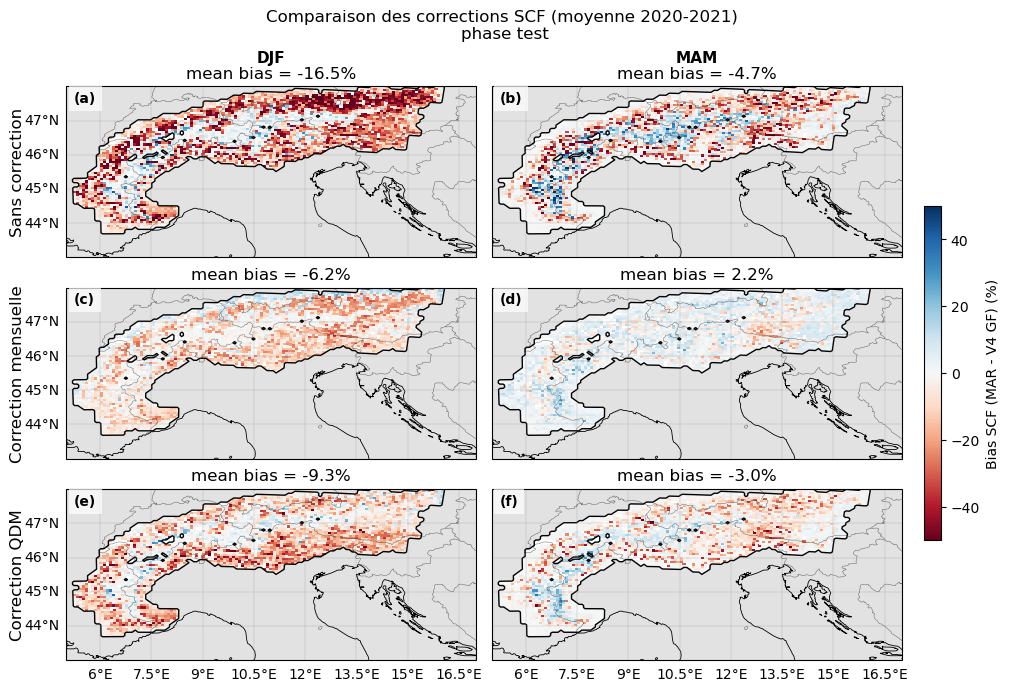

In [21]:
time_pd_v4 = all_v4_test.time.to_index()
season_labels = [get_season(t) for t in time_pd_v4]
all_mar_test= all_mar_test.assign_coords(season=('time', season_labels))
all_mar_qdm_px_test= all_mar_qdm_test.assign_coords(season=('time', season_labels))
all_mar_corrige_test= all_mar_corr_test.assign_coords(season=('time', season_labels))
all_v4_test= all_v4_test.assign_coords(season=('time', season_labels))

winter_brut_test   = get_seasonal_mean(all_mar_test, 'DJF', years_test)
spring_brut_test   = get_seasonal_mean(all_mar_test, 'MAM', years_test)

winter_corr_test   = get_seasonal_mean(all_mar_corrige_test, 'DJF', years_test)
spring_corr_test   = get_seasonal_mean(all_mar_corrige_test, 'MAM', years_test)

winter_qm_test     = get_seasonal_mean(all_mar_qdm_px_test, 'DJF', years_test)
spring_qm_test    = get_seasonal_mean(all_mar_qdm_px_test, 'MAM', years_test)


winter_v4_test= get_seasonal_mean(all_v4_test, 'DJF', years_test)
spring_v4_test = get_seasonal_mean(all_v4_test, 'MAM', years_test)


rows = [
    ('Sans correction',      winter_brut_test  - winter_v4_test, spring_brut_test - spring_v4_test),
    ('Correction mensuelle', winter_corr_test  - winter_v4_test , spring_corr_test  - spring_v4_test),
    ('Correction QDM',        winter_qm_test    - winter_v4_test, spring_qm_test    - spring_v4_test),
]


fig, axs = plt.subplots(3, 2, figsize=(10, 6.8),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)
grey_mask = np.where(alps, np.nan, 0.2)

for i, (titre, diff_w, diff_s) in enumerate(rows):
    for j, (ax, diff, season_name) in enumerate([
        (axs[i,0], diff_w.where(alps_ice==True), 'DJF'),
        (axs[i,1], diff_s.where(alps_ice==True), 'MAM')
    ]):
        idx = i * 2 + j
        lettre = f"({chr(97 + idx)})" 
        ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                      cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree())
        im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, diff,
                           cmap='RdBu', vmin=-50, vmax=50,
                           transform=ccrs.PlateCarree())
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
        ax.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0)
        if i == 0:
            ax.text(0.5, 1.12, f"{season_name}", transform=ax.transAxes,
                    fontsize=11, ha='center', va='bottom', fontweight = 'bold')

        if j == 0:
            ax.text(-0.1, 0.5, titre, transform=ax.transAxes,
                    fontsize=12, ha='right', va='center', rotation=90)
        biais_mean = float(np.nanmean(diff))
        ax.set_title(f"mean bias = {biais_mean:.1f}%", fontsize=12)
        ax.text(0.02, 0.97, lettre, transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='top',
                    bbox=dict(fc='white', ec='none', alpha=0.7))
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = False
        gl.bottom_labels = False
        if j == 0:
            gl.left_labels = True
        if i == 2:
            gl.bottom_labels = True
    
cbar = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.02, shrink=0.6)
cbar.set_label('Bias SCF (MAR - V4 GF) (%)', fontsize=10)
plt.suptitle('Comparaison des corrections SCF (moyenne 2020-2021) \nphase test', size=12)
#plt.savefig('/home/mougina/mes_analyses/correction_MAR/comparaison_corrections_SCF_test.png', dpi=100)
plt.show()

Synthese des deux Graph de presentation

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


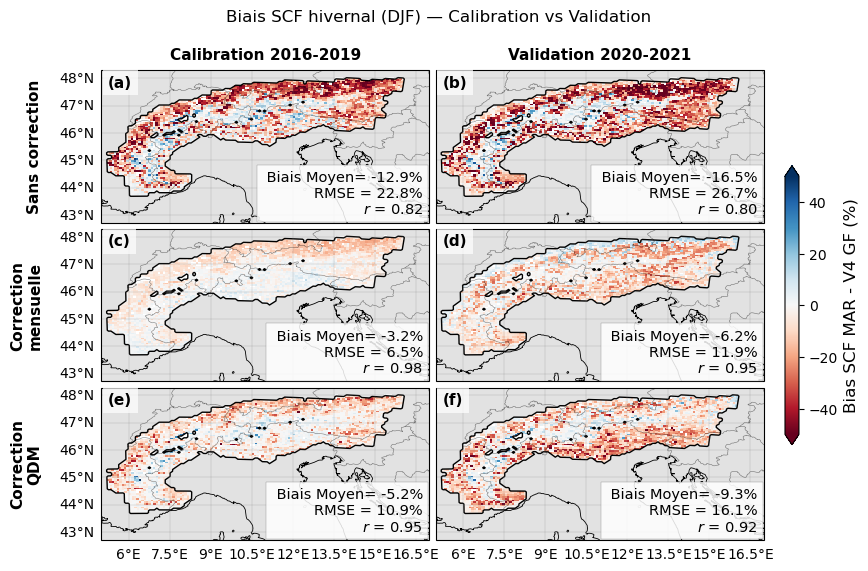

In [23]:
import scipy.stats as stats

fig, axs = plt.subplots(3, 2, figsize=(9, 6.1),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.02, 'hspace': 0.04})
grey_mask = np.where(alps, np.nan, 0.2)

rows = [
    ('Sans correction',      
     winter_brut   - winter_v4,      # calibration
     winter_brut_test - winter_v4_test),  # test
    ('Correction\nmensuelle', 
     winter_corr   - winter_v4,
     winter_corr_test - winter_v4_test),
    ('Correction\nQDM',        
     winter_qm     - winter_v4,
     winter_qm_test - winter_v4_test),
]

col_titles = ['Calibration 2016-2019', 'Validation 2020-2021']

for i, (titre, diff_calib, diff_test) in enumerate(rows):
    for j, (ax, diff, col_title) in enumerate([
        (axs[i,0], diff_calib.where(alps_ice==True), col_titles[0]),
        (axs[i,1], diff_test.where(alps_ice==True),  col_titles[1])
    ]):
        
        ax.set_adjustable('datalim')
        
        idx = i * 2 + j
        idx = i * 2 + j
        lettre = f"({chr(97 + idx)})"
        ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                      cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree())
        im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, diff,
                           cmap='RdBu', vmin=-50, vmax=50,
                           transform=ccrs.PlateCarree())
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
        ax.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0)

        if i == 0:
            ax.text(0.5, 1.05, col_title, transform=ax.transAxes,
                    fontsize=11, ha='center', va='bottom', fontweight='bold')

        if j == 0:
            ax.text(-0.18, 0.5, titre, transform=ax.transAxes,
                    fontsize=11, ha='right', va='center', rotation=90, fontweight='bold',ma='center')
        
        biais_mean = float(np.nanmean(diff))
        ref_complete = winter_v4 if j == 0 else winter_v4_test
        if j == 0:  
            mod_complete = winter_brut if i == 0 else (winter_corr if i == 1 else winter_qm)
        else:     
            mod_complete = winter_brut_test if i == 0 else (winter_corr_test if i == 1 else winter_qm_test)
        v_mod = mod_complete.where(alps_ice==True).values.flatten()
        v_ref = ref_complete.where(alps_ice==True).values.flatten()
        mask_valid = ~np.isnan(v_mod) & ~np.isnan(v_ref)
        rmse = float(np.sqrt(np.mean((v_mod[mask_valid] - v_ref[mask_valid]) ** 2)))
        r_val, _ = stats.pearsonr(v_mod[mask_valid], v_ref[mask_valid])    
        stats_text = f" Biais Moyen= {biais_mean:.1f}%\nRMSE = {rmse:.1f}%\n$r$ = {r_val:.2f}"
        ax.text(0.98, 0.04, stats_text, transform=ax.transAxes,
                fontsize=10.5, ha='right', va='bottom', zorder=5,
                bbox=dict(fc='white', ec='gray', lw=0.3, alpha=0.85))
        ax.text(0.02, 0.97, lettre, transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top',
                bbox=dict(fc='white', ec='none', alpha=0.7))
        
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
        gl.top_labels    = False
        gl.right_labels  = False
        gl.left_labels   = False
        gl.bottom_labels = False
        if j == 0:
            gl.left_labels = True
        if i == 2:
            gl.bottom_labels = True

fig.subplots_adjust(wspace=0.01, hspace=0.01)

cbar = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.03, shrink=0.7, extend='both', extendfrac=0.04)
cbar.set_label('Bias SCF MAR - V4 GF (%)', fontsize=12)

plt.suptitle('Biais SCF hivernal (DJF) — Calibration vs Validation', size=12, y=0.98)
plt.savefig('/home/mougina/mes_analyses_neige/comparaison_corrections_SCF_correction_combined.png', 
            dpi=200, bbox_inches='tight')
plt.show()

### Inversion de la formule LA23 sur 5ans

In [41]:
list_sd_brut = []
list_sd_corr = []
list_sd_qdm  = []
list_sd_double_brut = []
for yr in years_train: 
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
    rho_snow = ds_rho['RO1'].isel(outlay=0)
    SD = ds_m['ZN3']
    topo_numpy = sigma_topo_aligned.fillna(0).values
    denominateur = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + \
                   (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    denominateur_safe = denominateur.where(denominateur > 0, other=1e-10)
    scf_mar = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe) * 100)
    alps_ice_da = xr.DataArray(alps_ice, dims=['y', 'x'])
    scf_mar = scf_mar.where(alps_ice_da)

    scf_qdm  = qdm_appliquer(scf_mar, ds_quantiles_ref)
    scf_corr = corriger_biais_pixel(scf_mar, biais_pixel_mensuel)
    
    scf_corr_safe = (scf_corr / 100).clip(0, 0.999999999999)
    scf_qdm_safe  = (scf_qdm / 100).clip(0, 0.999999999999)
    SD_corr = np.atanh(scf_corr_safe) * denominateur_safe
    SD_qdm  = np.atanh(scf_qdm_safe) * denominateur_safe

    scf_mar = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe) * 100)
    scf_brut_safe = (scf_mar / 100).clip(0, 0.999999999999) 
    
    SD_double_brut = np.atanh(scf_brut_safe) * denominateur_safe
    SD_corr = SD_corr.clip(0, 6.0)
    SD_qdm  = SD_qdm.clip(0, 6.0)
    SD_doube_brut = SD_double_brut.clip(0, 6.0)

    list_sd_brut.append(SD.where(alps_ice_da))
    list_sd_corr.append(SD_corr.where(alps_ice_da))
    list_sd_qdm.append(SD_qdm.where(alps_ice_da))
    list_sd_double_brut.append(SD_double_brut.where(alps_ice_da))
    
all_sd_double_brut = xr.concat(list_sd_double_brut, dim ='time')
all_sd_brut = xr.concat(list_sd_brut, dim='time')
all_sd_corr = xr.concat(list_sd_corr, dim='time')
all_sd_qdm  = xr.concat(list_sd_qdm, dim='time')

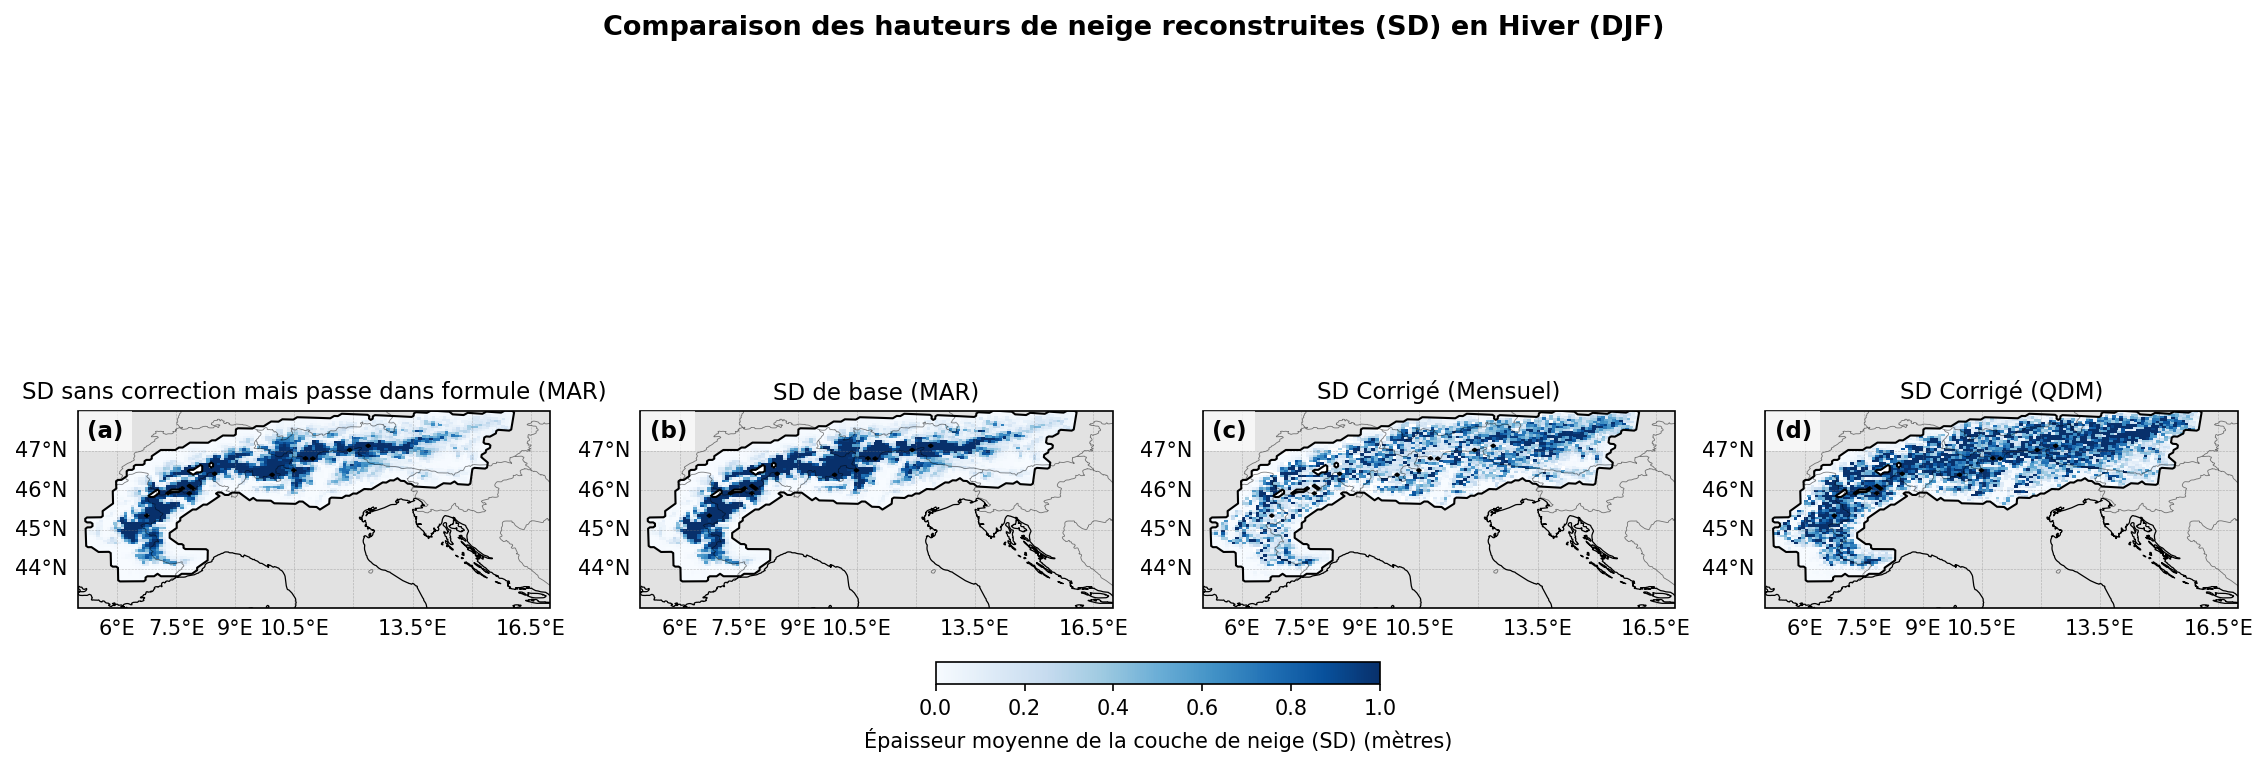

Épaisseur de neige au quantile 99% brut (m)    : 2.7962483525276185
Épaisseur de neige au quantile 99% QDM (m)     : 4.053275920783736
Épaisseur de neige au quantile 99% mensuel (m) : 2.9069392756389316
Épaisseur de neige max (m)    : 6.766839027404785
Épaisseur de neige max (m)     : 6.0
Épaisseur de neige max (m) : 6.0


In [42]:

time_pd_sd = all_sd_brut.time.to_index()
season_labels_sd = [get_season(t) for t in time_pd_sd]
all_sd_brut_total = all_sd_brut.assign_coords(season=('time', season_labels_sd))
all_sd_corr_total = all_sd_corr.assign_coords(season=('time', season_labels_sd))
all_sd_qdm_total  = all_sd_qdm.assign_coords(season=('time', season_labels_sd))
all_sd_double_brut_total = all_sd_double_brut.assign_coords(season=('time', season_labels_sd))

sd_double_brut_climatology = get_seasonal_mean(all_sd_double_brut_total, 'DJF', years_train).where(alps_ice_da)
sd_brut_climatology = get_seasonal_mean(all_sd_brut_total, 'DJF', years_train).where(alps_ice_da)
sd_corr_climatology = get_seasonal_mean(all_sd_corr_total, 'DJF', years_train).where(alps_ice_da)
sd_qdm_climatology  = get_seasonal_mean(all_sd_qdm_total, 'DJF', years_train).where(alps_ice_da)

plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'font.size':       10,
    'axes.titlesize':  11,
    'figure.dpi':      150,
})

fig, axs = plt.subplots(1, 4, figsize=(15, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)

panel_labels = ['(a)', '(b)', '(c)', '(d)']
datasets = [sd_double_brut_climatology,sd_brut_climatology, sd_corr_climatology, sd_qdm_climatology]
titles = ['SD sans correction mais passe dans formule (MAR)','SD de base (MAR)', 'SD Corrigé (Mensuel)', 'SD Corrigé (QDM)']

grey_mask = np.where(alps, np.nan, 0.2)
max_snow_depth = 1  

for i, ax in enumerate(axs):
    ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                  cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree(), zorder=1)
    
    im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, datasets[i],
                       cmap='Blues', vmin=0, vmax=max_snow_depth, transform=ccrs.PlateCarree(), zorder=2)
    
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.6, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5, zorder=3)
    ax.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0, transform=ccrs.PlateCarree(), zorder=4)
    
    ax.set_title(titles[i], fontsize=11)
    ax.text(0.02, 0.96, panel_labels[i], transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', zorder=5,
            bbox=dict(fc='white', ec='none', alpha=0.7))
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--', zorder=4)
    gl.top_labels = False
    gl.right_labels = False

cbar = fig.colorbar(im, ax=axs, location='bottom', fraction=0.04, pad=0.04, shrink=0.5)
cbar.set_label("Épaisseur moyenne de la couche de neige (SD) (mètres)", fontsize=10)

fig.suptitle('Comparaison des hauteurs de neige reconstruites (SD) en Hiver (DJF)', 
             fontsize=13, fontweight='bold')

#plt.savefig('/home/mougina/mes_analyses/comparaison_MAR_v4etv2/carte_hauteur_neige_SD_DJF_propre.png', dpi=100)
plt.show()
print('Épaisseur de neige au quantile 99% brut (m)    :', float(all_sd_brut_total.quantile(0.99)))
print('Épaisseur de neige au quantile 99% QDM (m)     :', float(all_sd_qdm_total.quantile(0.99)))
print('Épaisseur de neige au quantile 99% mensuel (m) :', float(all_sd_corr_total.quantile(0.99)))
print('Épaisseur de neige max (m)    :', float(all_sd_brut_total.max()))
print('Épaisseur de neige max (m)     :', float(all_sd_qdm_total.max()))
print('Épaisseur de neige max (m) :', float(all_sd_corr_total.max()))

# 2 eme Partie

ouverture MAR sur toute la periode 

In [14]:
years = range(1940, 2025)
lat1, lat2, lon1, lon2 =  43, 48, 5, 17  # Alpes

Inversion de la fonction, on retrouve SD apres correction DQM ou mens

fonction ligne de neige

In [15]:

altitude = ds_grid['SH'].values  
def calculer_ligne_neige_journaliere(scf_mar, altitude, alps_ice, seuil=50, n_pixels=100, n_pixels_min=10):
    alt_flat = altitude[alps_ice]
    n_temps = scf_mar.sizes['time']
    
    critere_1 = np.full(n_temps, np.nan)
    critere_2 = np.full(n_temps, np.nan)
    critere_3 = np.full(n_temps, np.nan)
    
    for t in range(n_temps):
        jour = scf_mar.isel(time=t).values
        scf_flat = jour[alps_ice]
        
        mask_valid = ~np.isnan(scf_flat)
        scf_v = scf_flat[mask_valid]
        alt_v = alt_flat[mask_valid]
        
        if len(scf_v) < 20:
            continue
        alt_avec_neige = alt_v[scf_v >= seuil]
        alt_sans_neige = alt_v[scf_v < seuil]
        
        # --- Fallback : on prend min(n_pixels disponibles, n_pixels souhaité) ---
        n_use_neige = min(n_pixels, len(alt_avec_neige))
        n_use_sans  = min(n_pixels, len(alt_sans_neige))
        
        if n_use_neige < n_pixels_min or n_use_sans < n_pixels_min:
            continue  # toujours NaN si vraiment trop peu de pixels
        
        critere_1[t] = np.mean(np.sort(alt_sans_neige)[-n_use_sans:])
        critere_2[t] = np.mean(np.sort(alt_avec_neige)[:n_use_neige])
        critere_3[t] = (critere_1[t] + critere_2[t]) / 2

    return (
        xr.DataArray(critere_1, coords=[scf_mar.time], dims=['time']),
        xr.DataArray(critere_2, coords=[scf_mar.time], dims=['time']),
        xr.DataArray(critere_3, coords=[scf_mar.time], dims=['time'])
    )

In [16]:


list_scf_annuel = []
list_ln1_brut, list_ln2_brut, list_ln3_brut = [], [], []
list_ln1_qdm,  list_ln2_qdm,  list_ln3_qdm  = [], [], []
list_ln1_corr, list_ln2_corr, list_ln3_corr = [], [], []
list_ln1_seuil, list_ln2_seuil, list_ln3_seuil = [], [], []

altitude = ds_grid['SH'].values  

for yr in years: 
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
    SD = ds_m['ZN3']
    rho_snow = calc_rho_mean(ds_rho, SD)
    topo_numpy = sigma_topo_aligned.fillna(0).values
    denominateur = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + \
                   (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    denominateur_safe = denominateur.where(denominateur > 0, other=1e-10)
    scf_mar = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe) * 100)
    alps_ice_da = xr.DataArray(alps_ice, dims=['y', 'x'])
    scf_mar = scf_mar.where(alps_ice_da)
    scf_seuil = xr.where(SD > 0.01, 100, 0)
    scf_seuil = scf_seuil.where(alps_ice_da)
    scf_qdm  = qdm_appliquer(scf_mar, ds_quantiles_ref)
    scf_corr = corriger_biais_pixel(scf_mar, biais_pixel_mensuel)
    
    scd_mar_jours  = xr.where(scf_mar > 50, 1, 0).sum(dim='time')
    scd_qdm_jours  = xr.where(scf_qdm > 50, 1, 0).sum(dim='time')
    scd_corr_jours = xr.where(scf_corr > 50, 1, 0).sum(dim='time')
    scd_seuil_jours = xr.where(scf_seuil > 50, 1, 0).sum(dim='time')
    
            ###scf annuel
    list_scf_annuel.append({
    'year'   : yr,
    'brut'   : float(np.nanmean(scf_mar.values)),
    'qdm'    : float(np.nanmean(scf_qdm.values)),
    'mensuel': float(np.nanmean(scf_corr.values)),
    'seuil'  : float(np.nanmean(scf_seuil.values)),})
    list_scf_annuel[-1].update({
        'scd_brut':    float(scd_mar_jours.where(alps_ice_da).mean()),
        'scd_qdm':     float(scd_qdm_jours.where(alps_ice_da).mean()),
        'scd_mensuel': float(scd_corr_jours.where(alps_ice_da).mean()),
        'scd_seuil':   float(scd_seuil_jours.where(alps_ice_da).mean())
    })
        ### ligne de neige
    ln1_brut, ln2_brut, ln3_brut = calculer_ligne_neige_journaliere(scf_mar,  altitude, alps_ice)
    ln1_qdm,  ln2_qdm,  ln3_qdm  = calculer_ligne_neige_journaliere(scf_qdm,  altitude, alps_ice)
    ln1_corr, ln2_corr, ln3_corr = calculer_ligne_neige_journaliere(scf_corr, altitude, alps_ice)
    ln1_seuil, ln2_seuil, ln3_seuil = calculer_ligne_neige_journaliere(scf_seuil, altitude, alps_ice)
    
    list_ln3_seuil.append(ln3_seuil.resample(time='1MS').median())
    list_ln3_brut.append(ln3_brut.resample(time='1MS').median())
    list_ln3_qdm.append(ln3_qdm.resample(time='1MS').median())
    list_ln3_corr.append(ln3_corr.resample(time='1MS').median())

    del scf_mar, scf_qdm, scf_corr, ds_m, ds_rho, scf_seuil
    
df_scf = pd.DataFrame(list_scf_annuel)
ligne_neige_brut = xr.concat(list_ln3_brut, dim='time')
ligne_neige_qdm  = xr.concat(list_ln3_qdm,  dim='time')
ligne_neige_corr = xr.concat(list_ln3_corr, dim='time')
ligne_neige_seuil = xr.concat(list_ln3_seuil, dim='time')
print("SCF shape:", df_scf.shape)
print("Ligne neige shape:", ligne_neige_qdm.shape)
print("Années:", ligne_neige_qdm.time.dt.year.values[[0,-1]])


Application mois 1...
Application mois 2...
Application mois 3...
Application mois 4...
Application mois 5...
Application mois 6...
Application mois 7...
Application mois 8...
Application mois 9...
Application mois 10...
Application mois 11...
Application mois 12...
Application mois 1...
Application mois 2...
Application mois 3...
Application mois 4...
Application mois 5...
Application mois 6...
Application mois 7...
Application mois 8...
Application mois 9...
Application mois 10...
Application mois 11...
Application mois 12...
Application mois 1...
Application mois 2...
Application mois 3...
Application mois 4...
Application mois 5...
Application mois 6...
Application mois 7...
Application mois 8...
Application mois 9...
Application mois 10...
Application mois 11...
Application mois 12...
Application mois 1...
Application mois 2...
Application mois 3...
Application mois 4...
Application mois 5...
Application mois 6...
Application mois 7...
Application mois 8...
Application mois 9...
A

In [17]:
ligne_neige_v4 = xr.concat(clim_v4, dim='time')

### Plot SCF et SCD annuel

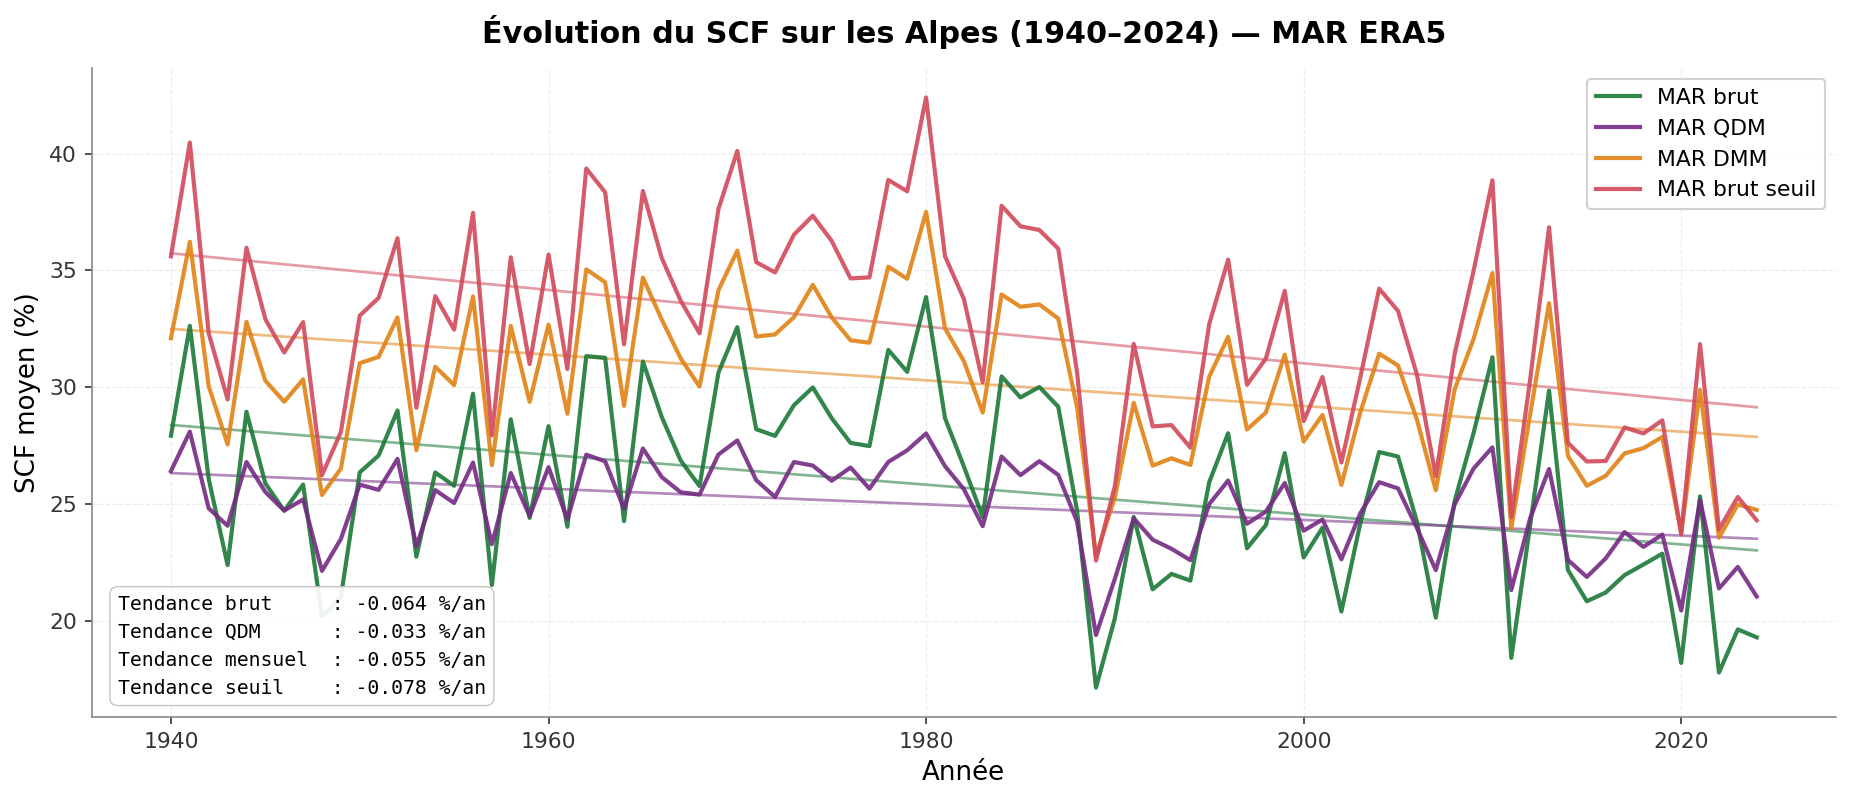

Tendance brut         : -0.0638 %/an  (soit -5.36% sur 84 ans)  | diff simple (dernier-premier) : -8.62%
Tendance QDM          : -0.0334 %/an  (soit -2.81% sur 84 ans)  | diff simple (dernier-premier) : -5.37%
Tendance corr         : -0.0549 %/an  (soit -4.61% sur 84 ans)  | diff simple (dernier-premier) : -7.34%
Tendance brut seuil   : -0.0784 %/an  (soit -6.59% sur 84 ans)  | diff simple (dernier-premier) : -11.29%


In [48]:
plt.rcParams.update({
    'font.family':     'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Nimbus Sans', 'Arial', 'DejaVu Sans'],
    'font.size':       12,
    'axes.titlesize':  14,
    'axes.edgecolor':  '#888888',
    'axes.linewidth':  0.8,
    'figure.dpi':      150,
})

# --- Couleurs harmonisées ---
c_brut, c_qdm, c_corr, c_seuil = '#1b7837', '#762a83', '#e08214', '#d1495b'

fig, ax = plt.subplots(figsize=(12.5, 5.5))

ax.plot(df_scf.year, df_scf.brut,    color=c_brut,  label='MAR brut',       linewidth=2, alpha=0.9)
ax.plot(df_scf.year, df_scf.qdm,     color=c_qdm,   label='MAR QDM',        linewidth=2, alpha=0.9)
ax.plot(df_scf.year, df_scf.mensuel, color=c_corr,  label='MAR DMM',    linewidth=2, alpha=0.9)
ax.plot(df_scf.year, df_scf.seuil,   color=c_seuil, label='MAR brut seuil', linewidth=2, alpha=0.9)

tendances = {}
for col, color in [('brut', c_brut), ('qdm', c_qdm), ('mensuel', c_corr), ('seuil', c_seuil)]:
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_scf.year, df_scf[col])
    tendances[col] = slope
    fit = intercept + slope * df_scf.year
    sig = p_value < 0.05
    ax.plot(df_scf.year, fit, color=color, linestyle='-' if sig else '--',
            linewidth=1.3, alpha=0.55, zorder=1)

n_annees = df_scf.year.iloc[-1] - df_scf.year.iloc[0]
stats_text = (
    f"Tendance brut     : {tendances['brut']:+.3f} %/an\n"
    f"Tendance QDM      : {tendances['qdm']:+.3f} %/an\n"
    f"Tendance mensuel  : {tendances['mensuel']:+.3f} %/an\n"
    f"Tendance seuil    : {tendances['seuil']:+.3f} %/an"
)
ax.text(0.015, 0.03, stats_text, transform=ax.transAxes,
        fontsize=9.5, ha='left', va='bottom', linespacing=1.6, family='monospace',
        bbox=dict(facecolor='white', edgecolor='#bbbbbb', linewidth=0.6,
                  alpha=0.92, boxstyle='round,pad=0.4'))

ax.set_ylabel('SCF moyen (%)', fontsize=12.5)
ax.set_xlabel('Année', fontsize=12.5)
ax.set_title("Évolution du SCF sur les Alpes (1940–2024) — MAR ERA5", fontsize=14.5, fontweight='bold', pad=12)

ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#cccccc',
          fontsize=10.5, framealpha=0.9)
ax.grid(alpha=0.25, linewidth=0.6, linestyle='--')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_edgecolor('#888888')
    ax.spines[spine].set_linewidth(0.8)

ax.tick_params(axis='both', labelsize=10.5, colors='#333333')

plt.tight_layout()
plt.savefig('/home/mougina/mes_analyses_neige/Evolution_SCF_moy_MAR_Corr.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

for col, label in [('brut', 'brut'), ('qdm', 'QDM'), ('mensuel', 'corr'), ('seuil', 'brut seuil')]:
    print(f"Tendance {label:12s} : {tendances[col]:+.4f} %/an  "
          f"(soit {tendances[col]*n_annees:+.2f}% sur {n_annees} ans)  "
          f"| diff simple (dernier-premier) : {df_scf[col].iloc[-1] - df_scf[col].iloc[0]:+.2f}%")


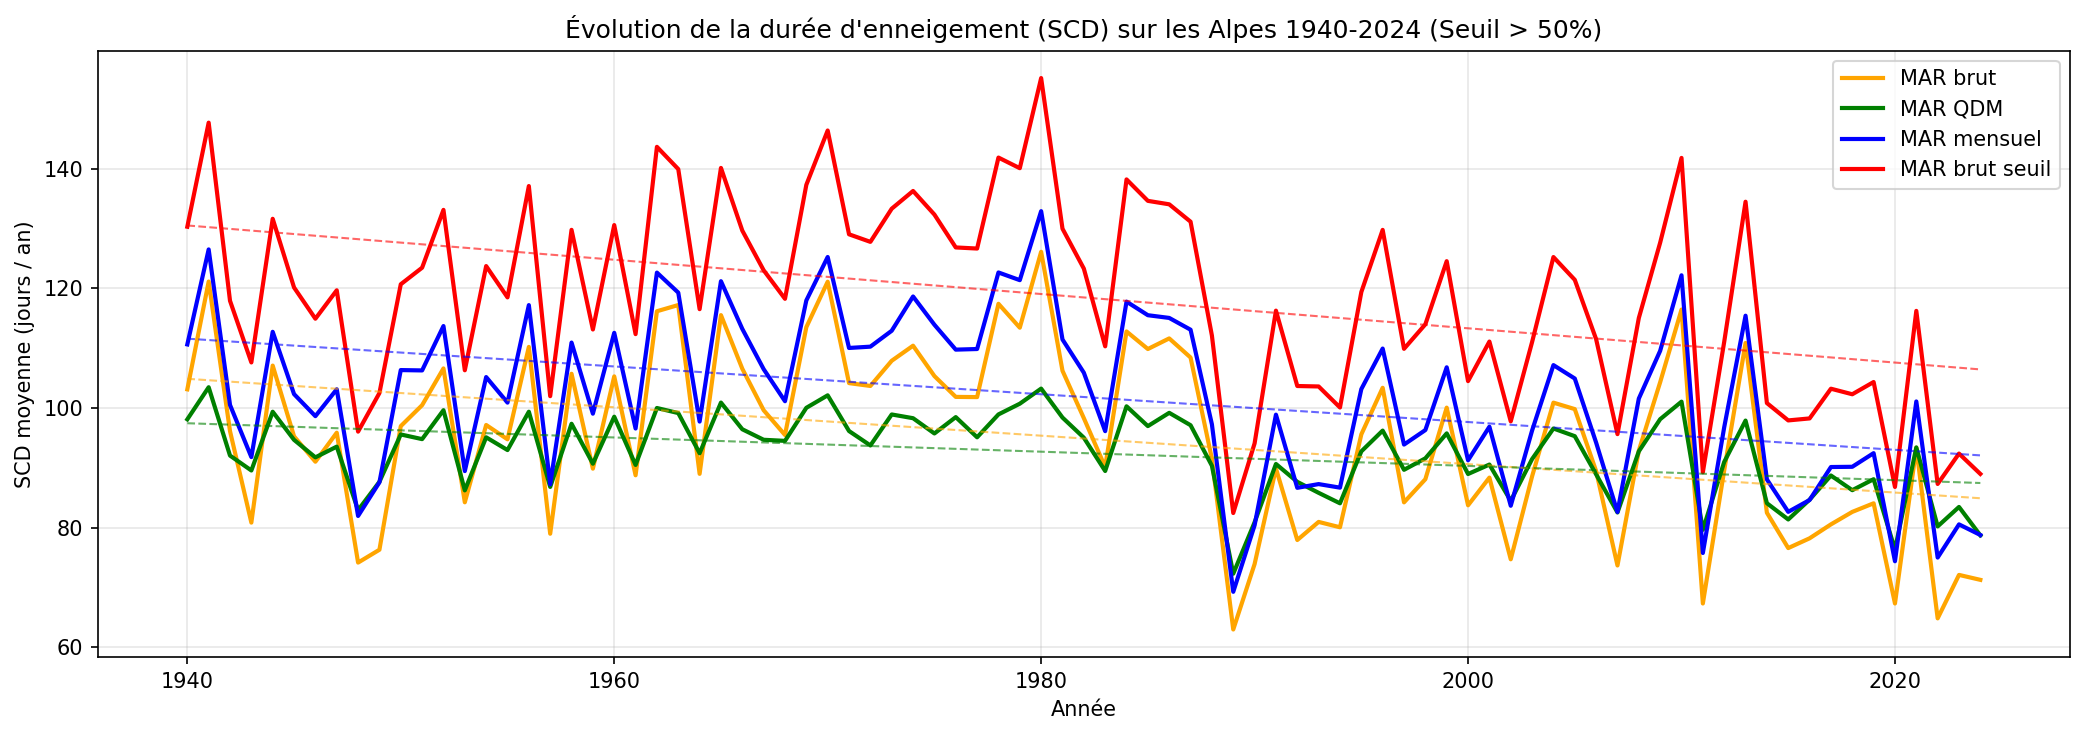

Tendance SCD brut         : -0.2377 jours/an  (soit -19.97 jours sur 84 ans)  | diff simple (dernier-premier) : -31.84 jours
Tendance SCD QDM          : -0.1189 jours/an  (soit -9.99 jours sur 84 ans)  | diff simple (dernier-premier) : -19.40 jours
Tendance SCD corr         : -0.2323 jours/an  (soit -19.51 jours sur 84 ans)  | diff simple (dernier-premier) : -31.85 jours
Tendance SCD brut seuil   : -0.2865 jours/an  (soit -24.06 jours sur 84 ans)  | diff simple (dernier-premier) : -41.32 jours


In [19]:
plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'font.size':       10,
    'axes.titlesize':  12,
    'figure.dpi':      150,
})

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_scf.year, df_scf.scd_brut,    color='orange', label='MAR brut',       linewidth=2)
ax.plot(df_scf.year, df_scf.scd_qdm,     color='green',  label='MAR QDM',        linewidth=2)
ax.plot(df_scf.year, df_scf.scd_mensuel, color='blue',   label='MAR mensuel',    linewidth=2)
ax.plot(df_scf.year, df_scf.scd_seuil,   color='red',    label='MAR brut seuil', linewidth=2)

# Régression linéaire (tendance) pour chaque version
tendances_scd = {}
for col, color in [('scd_brut', 'orange'), ('scd_qdm', 'green'), ('scd_mensuel', 'blue'), ('scd_seuil', 'red')]:
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_scf.year, df_scf[col])
    tendances_scd[col] = slope
    fit = intercept + slope * df_scf.year
    ax.plot(df_scf.year, fit, color=color, linestyle='--', linewidth=1, alpha=0.6)

ax.set_ylabel('SCD moyenne (jours / an)')
ax.set_xlabel('Année')
ax.set_title("Évolution de la durée d'enneigement (SCD) sur les Alpes 1940-2024 (Seuil > 50%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig('/home/mougina/mes_analyses/correction_MAR/Evolution_SCD_moy_MAR_Corr.png', dpi=150)
plt.show()

n_annees = df_scf.year.iloc[-1] - df_scf.year.iloc[0]
for col, label in [('scd_brut', 'brut'), ('scd_qdm', 'QDM'), ('scd_mensuel', 'corr'), ('scd_seuil', 'brut seuil')]:
    print(f"Tendance SCD {label:12s} : {tendances_scd[col]:+.4f} jours/an  "
          f"(soit {tendances_scd[col]*n_annees:+.2f} jours sur {n_annees} ans)  "
          f"| diff simple (dernier-premier) : {df_scf[col].iloc[-1] - df_scf[col].iloc[0]:+.2f} jours")

# Ligne de neige 

In [20]:
months_per_year = 12
years_unique = np.unique(ligne_neige_qdm.time.dt.year.values)
n_years = len(years_unique)

monthly_ln_qdm = np.full((n_years, months_per_year), np.nan)
for iy, yr in enumerate(years_unique):
    for m in range(1, 13):
        vals = ligne_neige_qdm.sel(
            time=(ligne_neige_qdm.time.dt.year == yr) & 
                 (ligne_neige_qdm.time.dt.month == m))
        if len(vals) > 0:
            monthly_ln_qdm[iy, m-1] = float(vals.values)

monthly_ln_corr = np.full((n_years, months_per_year), np.nan)
for iy, yr in enumerate(years_unique):
    for m in range(1, 13):
        vals = ligne_neige_corr.sel(
            time=(ligne_neige_corr.time.dt.year == yr) & 
                 (ligne_neige_corr.time.dt.month == m))
        if len(vals) > 0:
            monthly_ln_corr[iy, m-1] = float(vals.values)


monthly_ln_brut = np.full((n_years, months_per_year), np.nan)
for iy, yr in enumerate(years_unique):
    for m in range(1, 13):
        vals = ligne_neige_brut.sel(
            time=(ligne_neige_brut.time.dt.year == yr) & 
                 (ligne_neige_brut.time.dt.month == m))
        if len(vals) > 0:
            monthly_ln_brut[iy, m-1] = float(vals.values)

monthly_ln_seuil= np.full((n_years, months_per_year), np.nan)
for iy, yr in enumerate(years_unique):
    for m in range(1, 13):
        vals = ligne_neige_seuil.sel(
            time=(ligne_neige_seuil.time.dt.year == yr) & 
                 (ligne_neige_seuil.time.dt.month == m))
        if len(vals) > 0:
            monthly_ln_seuil[iy, m-1] = float(vals.values)

In [21]:

slope_qdm = np.full(months_per_year, np.nan);   pvalue_qdm = np.full(months_per_year, np.nan)
slope_corr = np.full(months_per_year, np.nan); pvalue_corr = np.full(months_per_year, np.nan)
slope_brut = np.full(months_per_year, np.nan);  pvalue_brut = np.full(months_per_year, np.nan)
slope_seuil = np.full(months_per_year, np.nan);  pvalue_seuil = np.full(months_per_year, np.nan)
for imonth in range(months_per_year):

    mask_qdm = ~np.isnan(monthly_ln_qdm[:, imonth])
    if mask_qdm.sum() > 10:
        reg_qdm = stats.linregress(np.where(mask_qdm)[0], monthly_ln_qdm[mask_qdm, imonth])
        slope_qdm[imonth], pvalue_qdm[imonth] = reg_qdm.slope, reg_qdm.pvalue
        

    mask_corr = ~np.isnan(monthly_ln_corr[:, imonth])
    if mask_corr.sum() > 10:
        reg_corr = stats.linregress(np.where(mask_corr)[0], monthly_ln_corr[mask_corr, imonth])
        slope_corr[imonth], pvalue_corr[imonth] = reg_corr.slope, reg_corr.pvalue
        

    mask_brut = ~np.isnan(monthly_ln_brut[:, imonth])
    if mask_brut.sum() > 10:
        reg_brut = stats.linregress(np.where(mask_brut)[0], monthly_ln_brut[mask_brut, imonth])
        slope_brut[imonth], pvalue_brut[imonth] = reg_brut.slope, reg_brut.pvalue
        
    mask_seuil = ~np.isnan(monthly_ln_seuil[:, imonth])
    if mask_seuil.sum() > 10:
        reg_seuil = stats.linregress(np.where(mask_seuil)[0], monthly_ln_seuil[mask_seuil, imonth])
        slope_seuil[imonth], pvalue_seuil[imonth] = reg_seuil.slope, reg_seuil.pvalue

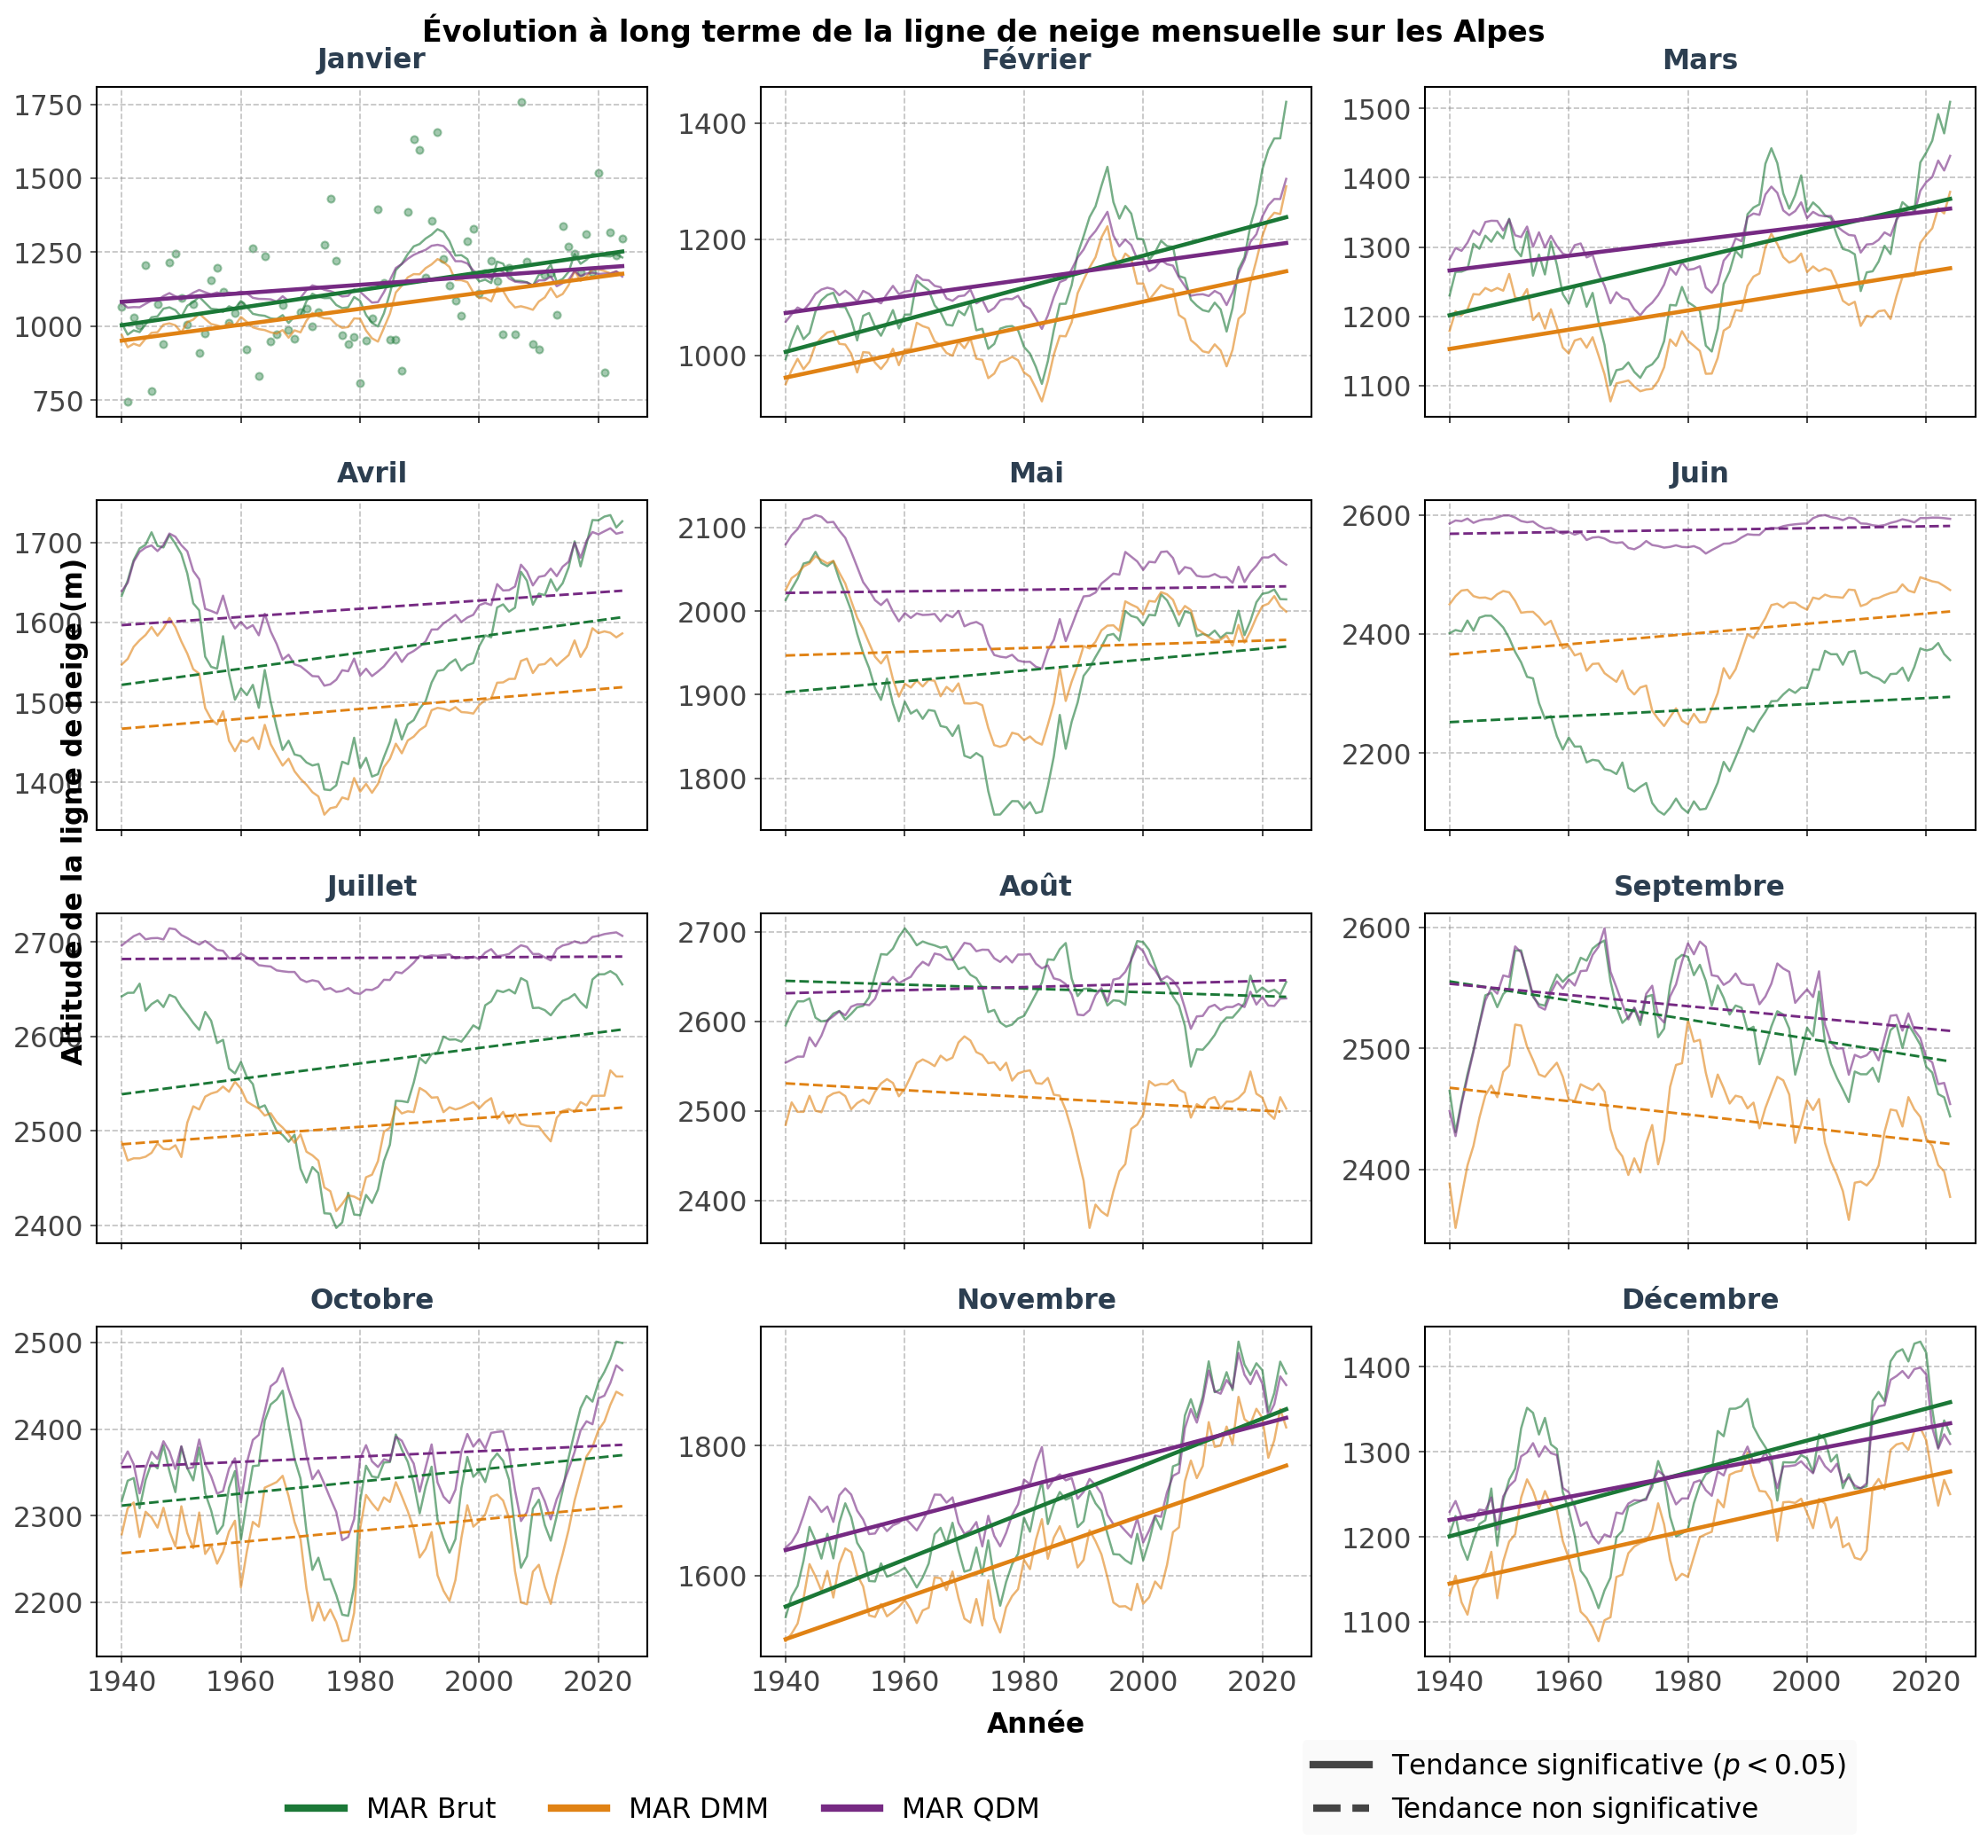

In [22]:

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Nimbus Sans', 'DejaVu Sans'],
    'font.size': 15,
    'axes.titlesize': 15,
    'axes.edgecolor': '#888888',   
    'axes.linewidth': 1.0     })
mois_noms = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
             'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

fig, axs = plt.subplots(4, 3, figsize=(16, 15), sharey=False)
axs_flat = axs.flatten()

# Couleurs harmonisées
c_qdm, c_corr, c_brut = '#762a83', '#e08214', '#1b7837'

for i in range(months_per_year):
    ax = axs_flat[i]
    ax.set_title(mois_noms[i], color='#2c3e50', weight='bold', pad=10)
    lbl_brut = 'MAR Brut' if i == 0 else None
    lbl_corr = 'MAR DMM' if i == 0 else None
    lbl_qdm  = 'MAR QDM' if i == 0 else None
    

    # --- 3. PRODUIT : BRUT ---
    roll_brut = pd.Series(monthly_ln_brut[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(years_unique, roll_brut, color=c_brut, linewidth=1.2, alpha=0.6, zorder=2)
    
    # if i == 0:
    #     roll_std_brut = pd.Series(monthly_ln_brut[:, i]).rolling(window=10, min_periods=3, center=True).std()
    #     ax.fill_between(years_unique, roll_brut - roll_std_brut, roll_brut + roll_std_brut,
    #                   color=c_brut, alpha=0.12, zorder=1, linewidth=0)
    # if i == 0:
    #     roll_std_corr = pd.Series(monthly_ln_corr[:, i]).rolling(window=10, min_periods=3, center=True).std()
    #     ax.fill_between(years_unique, roll_corr - roll_std_corr, roll_corr + roll_std_corr,
    #                  color=c_corr, alpha=0.12, zorder=1, linewidth=0)
    # if i == 0:
    #     roll_std_qdm = pd.Series(monthly_ln_qdm[:, i]).rolling(window=10, min_periods=3, center=True).std()
    #     ax.fill_between(years_unique, roll_qdm - roll_std_qdm, roll_qdm + roll_std_qdm,
    #                  color=c_qdm, alpha=0.12, zorder=1, linewidth=0)
    #if i == 0:
    #   ax.scatter(years_unique, monthly_ln_qdm[:, i], color=c_qdm, alpha=0.25, s=15, zorder=1)
    if i == 0:
        ax.scatter(years_unique, monthly_ln_brut[:, i], color=c_brut, alpha=0.4, s=15, zorder=1)
    if not np.isnan(slope_brut[i]):
        sig = pvalue_brut[i] < 0.05
        style_l = 'solid' if sig else 'dashed'
        largeur_l = 2.2 if sig else 1.4
        mask = ~np.isnan(monthly_ln_brut[:, i])
        x_reg = np.where(mask)[0]
        intercept_local = np.nanmean(monthly_ln_brut[:, i]) - slope_brut[i] * np.mean(x_reg)
        ax.plot(years_unique[mask], intercept_local + slope_brut[i] * x_reg, 
                color=c_brut, linestyle=style_l, linewidth=largeur_l, zorder=4, label=lbl_brut)

    roll_corr = pd.Series(monthly_ln_corr[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(years_unique, roll_corr, color=c_corr, linewidth=1.2, alpha=0.6, zorder=2)
    
    if not np.isnan(slope_corr[i]):
        sig = pvalue_corr[i] < 0.05
        style_l = 'solid' if sig else 'dashed'
        largeur_l = 2.2 if sig else 1.4
        mask = ~np.isnan(monthly_ln_corr[:, i])
        x_reg = np.where(mask)[0]
        intercept_local = np.nanmean(monthly_ln_corr[:, i]) - slope_corr[i] * np.mean(x_reg)
        ax.plot(years_unique[mask], intercept_local + slope_corr[i] * x_reg, 
                color=c_corr, linestyle=style_l, linewidth=largeur_l, zorder=4, label=lbl_corr)
        
    roll_qdm = pd.Series(monthly_ln_qdm[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(years_unique, roll_qdm, color=c_qdm, linewidth=1.2, alpha=0.6, zorder=2)
    
    if not np.isnan(slope_qdm[i]):
        sig = pvalue_qdm[i] < 0.05
        style_l = 'solid' if sig else 'dashed'
        largeur_l = 2.2 if sig else 1.4
        mask = ~np.isnan(monthly_ln_qdm[:, i])
        x_reg = np.where(mask)[0]
        intercept_local = np.nanmean(monthly_ln_qdm[:, i]) - slope_qdm[i] * np.mean(x_reg)
        ax.plot(years_unique[mask], intercept_local + slope_qdm[i] * x_reg, 
                color=c_qdm, linestyle=style_l, linewidth=largeur_l, zorder=4, label=lbl_qdm)

    ax.yaxis.set_tick_params(labelleft=True, labelsize=15, colors='#222222')  # au lieu de #444444
    ax.xaxis.set_tick_params(labelbottom=True, labelsize=15, colors='#222222', rotation=0)

    ax.grid(True, linestyle='--', alpha=0.6, color='#999999')
    
    # 1. On force l'affichage des altitudes 
    ax.yaxis.set_tick_params(labelleft=True, labelsize=15, colors='#444444')
    
    # 2. Gestion de la ligne du bas pour l
    if i >= 9:
        ax.xaxis.set_tick_params(labelbottom=True, labelsize=15, colors='#444444', rotation=0)
    else:
        ax.xaxis.set_tick_params(labelbottom=False)


    # Configuration d'un cadre noir complet sur les 4 côtés
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)      # Force l'affichage du côté
        ax.spines[spine].set_color('black')     # Met la bordure en noir
        ax.spines[spine].set_linewidth(1.0)     # Ajuste l'épaisseur du cadre (à modifier selon tes goûts)

# Label de l'axe X pour les trois graphiques du bas
for ax in axs_flat[10:11]:
    ax.set_xlabel('Année', fontsize=15, fontweight='bold', labelpad=8)

# --- Gestion des légendes claires ---
leg1 =fig.legend(loc='lower center', bbox_to_anchor=(0.35, 0.01), ncol=3, frameon=False, fontsize=15)

legend_elements = [
    Line2D([0], [0], color='#444444', linestyle='-', linewidth=2, label='Tendance significative ($p < 0.05$)'),
    Line2D([0], [0], color='#444444', linestyle='--', linewidth=1.4, label='Tendance non significative')
]
leg2 = fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.78, 0.01), ncol=1, frameon=True, facecolor='#f9f9f9', edgecolor='none', fontsize=15)
for line in leg1.get_lines():
    line.set_linewidth(4.0)
for line in leg2.get_lines():
    line.set_linewidth(4.0)
# Titres globaux
fig.text(0.073, 0.53, 'Altitude de la ligne de neige (m)', va='center', ha='center', rotation='vertical', fontsize=15, weight='bold')
plt.suptitle('Évolution à long terme de la ligne de neige mensuelle sur les Alpes', size=16, weight='bold', y=0.93)
plt.savefig('/home/mougina/mes_analyses_neige/comparaison_corrections_ligne_neige_avec100points.png', dpi=200, bbox_inches='tight')
plt.tight_layout(rect=[0.03, 0.05, 0.98, 0.96])
plt.show()

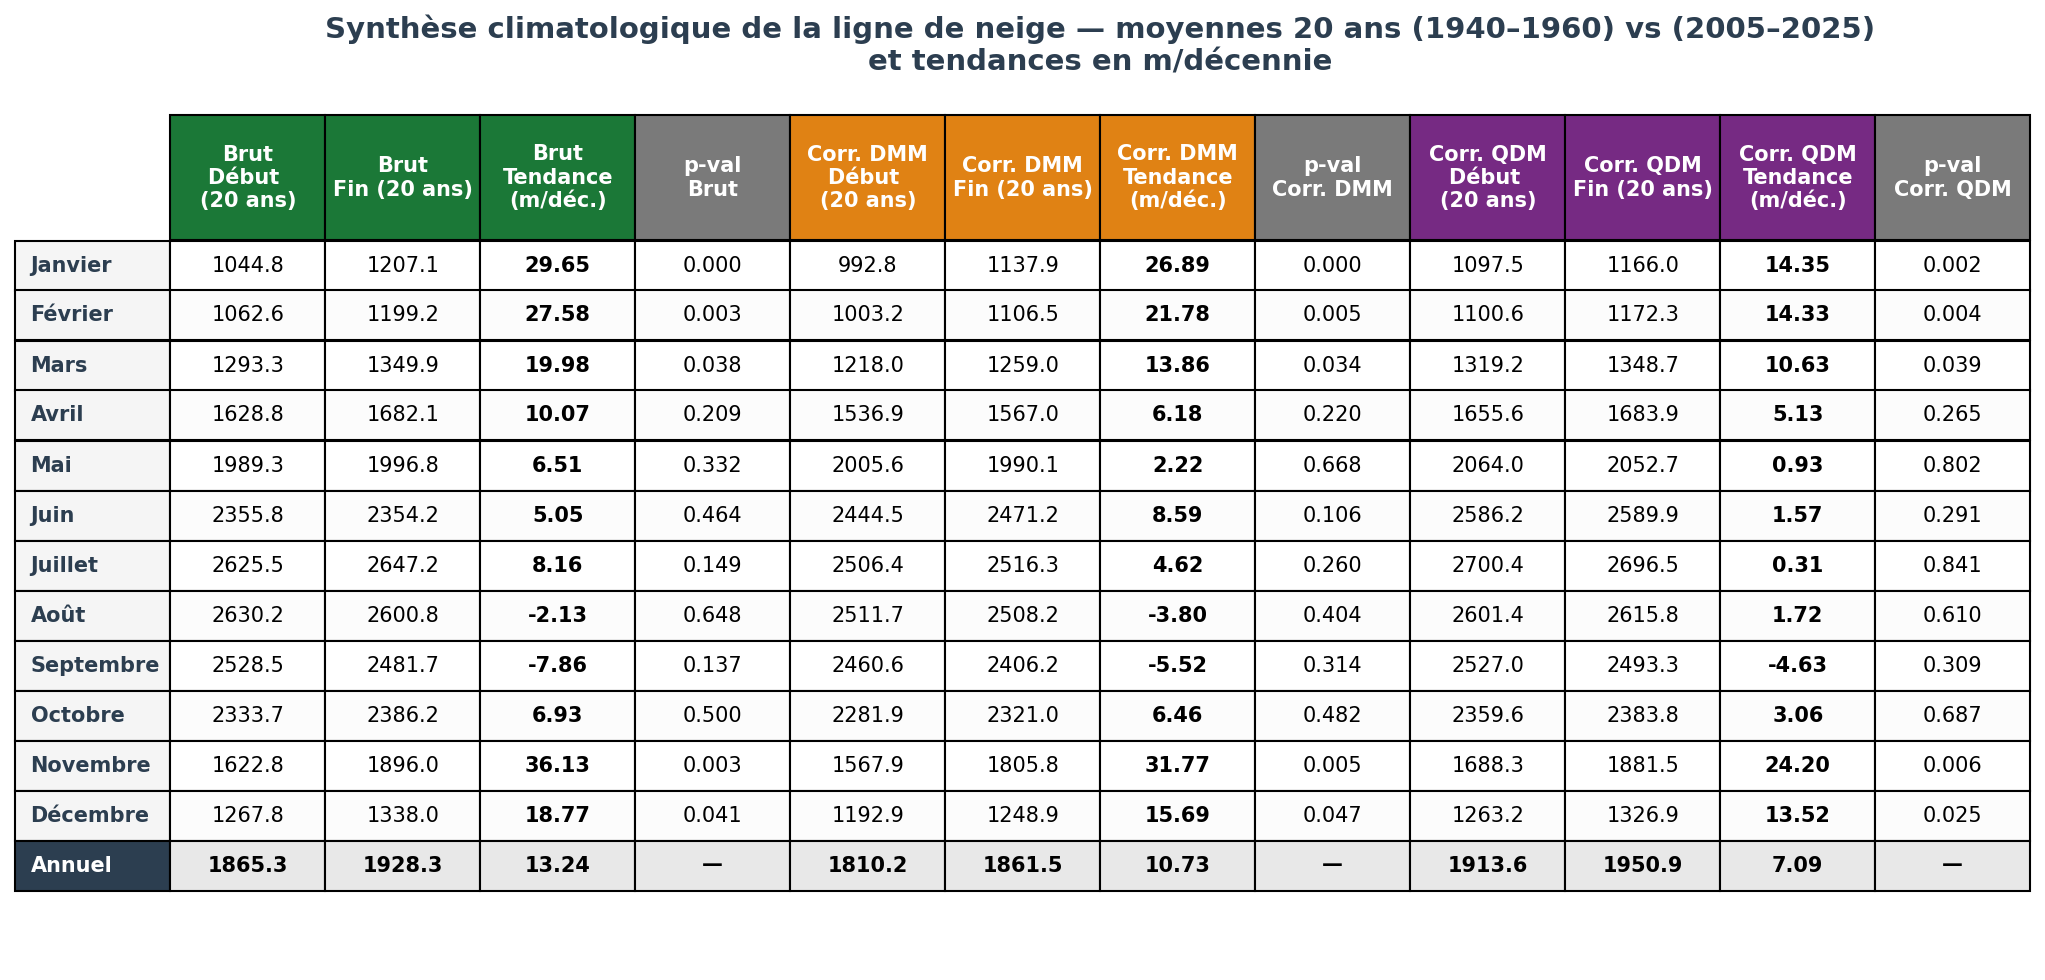

In [23]:
annee_debut = 1940  
annee_fin   = 2025  

mask_debut = (years_unique >= annee_debut) & (years_unique < annee_debut + 20)
mask_fin   = (years_unique >= annee_fin - 20) & (years_unique < annee_fin)

debut_brut = np.nanmean(monthly_ln_brut[mask_debut, :], axis=0)
fin_brut   = np.nanmean(monthly_ln_brut[mask_fin, :], axis=0)

debut_corr = np.nanmean(monthly_ln_corr[mask_debut, :], axis=0)
fin_corr   = np.nanmean(monthly_ln_corr[mask_fin, :], axis=0)

debut_qdm  = np.nanmean(monthly_ln_qdm[mask_debut, :], axis=0)
fin_qdm    = np.nanmean(monthly_ln_qdm[mask_fin, :], axis=0)

tendance_brut = slope_brut * 10
tendance_corr = slope_corr * 10
tendance_qdm  = slope_qdm * 10
df_visuel = pd.DataFrame({
    'Brut\nDébut \n(20 ans)':      np.round(debut_brut, 1),
    'Brut\nFin (20 ans)':        np.round(fin_brut, 1),
    'Brut\nTendance\n(m/déc.)':  np.round(tendance_brut, 2),
    'p-val\nBrut':                np.round(pvalue_brut, 3),

    'Corr. DMM\nDébut \n(20 ans)': np.round(debut_corr, 1),
    'Corr. DMM\nFin (20 ans)':   np.round(fin_corr, 1),
    'Corr. DMM\nTendance\n(m/déc.)': np.round(tendance_corr, 2),
    'p-val\nCorr. DMM':          np.round(pvalue_corr, 3),

    'Corr. QDM\nDébut \n(20 ans)':  np.round(debut_qdm, 1),
    'Corr. QDM\nFin (20 ans)':    np.round(fin_qdm, 1),
    'Corr. QDM\nTendance\n(m/déc.)': np.round(tendance_qdm, 2),
    'p-val\nCorr. QDM':           np.round(pvalue_qdm, 3),
}, index=mois_noms)

cols_pval = [c for c in df_visuel.columns if 'p-val' in c]
cols_val  = [c for c in df_visuel.columns if c not in cols_pval]

ligne_annuelle = pd.Series(index=df_visuel.columns, dtype=float)
ligne_annuelle[cols_val] = df_visuel[cols_val].mean(axis=0)
df_visuel.loc['Annuel'] = ligne_annuelle
df_visuel.loc['Annuel', cols_pval] = np.nan  


df_affiche = df_visuel.copy()
for c in cols_pval:
    df_affiche[c] = df_affiche[c].apply(lambda v: '—' if pd.isna(v) else f"{v:.3f}")
for c in cols_val:
    df_affiche[c] = df_affiche[c].apply(lambda v: f"{v:.2f}" if 'Tendance' in c else f"{v:.1f}")


fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')

table_png = ax.table(
    cellText=df_affiche.values,
    rowLabels=df_affiche.index,
    colLabels=df_affiche.columns,
    cellLoc='center',
    loc='center'
)

table_png.auto_set_font_size(False)
table_png.set_fontsize(10)
table_png.scale(1.0, 2.0)

couleur_brut  = '#1b7837'  
couleur_corr  = '#e08214' 
couleur_qdm   = '#762a83'  
couleur_pval  = '#7a7a7a'  
for (row, col), cell in table_png.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        if col in [0, 1, 2]:
            cell.set_facecolor(couleur_brut)
        elif col == 3:
            cell.set_facecolor(couleur_pval)
        elif col in [4, 5, 6]:
            cell.set_facecolor(couleur_corr)
        elif col == 7:
            cell.set_facecolor(couleur_pval)
        elif col in [8, 9, 10]:
            cell.set_facecolor(couleur_qdm)
        elif col == 11:
            cell.set_facecolor(couleur_pval)
        cell.set_height(cell.get_height() * 2.5)
    elif col == -1:
        is_annuel = df_affiche.index[row - 1] == 'Annuel'
        cell.set_text_props(weight='bold', color='#2c3e50' if not is_annuel else 'white')
        cell.set_facecolor('#f5f5f5' if not is_annuel else '#2c3e50')

    else:
        is_annuel = df_affiche.index[row - 1] == 'Annuel'
        if is_annuel:
            cell.set_facecolor('#e8e8e8')
            cell.set_text_props(weight='bold')
        else:
            cell.set_facecolor('#fcfcfc' if row % 2 == 0 else '#ffffff')

        if col in [2, 6, 10]:
            cell.set_text_props(weight='bold')

plt.title(
    f"Synthèse climatologique de la ligne de neige — moyennes 20 ans "
    f"({annee_debut}–{annee_debut+20}) vs ({annee_fin-20}–{annee_fin})\n"
    f"et tendances en m/décennie",
    fontsize=14, weight='bold', pad=30, color='#2c3e50'
, y = 0.9)

chemin_export = '/home/mougina/mes_analyses_neige/tableau_complet_ligne_neige_100points1940-2025.png'
plt.savefig(chemin_export, dpi=300, bbox_inches='tight')
plt.show()

Verification avec deux MAR brut avec LA23 ou avec un seuil binaire

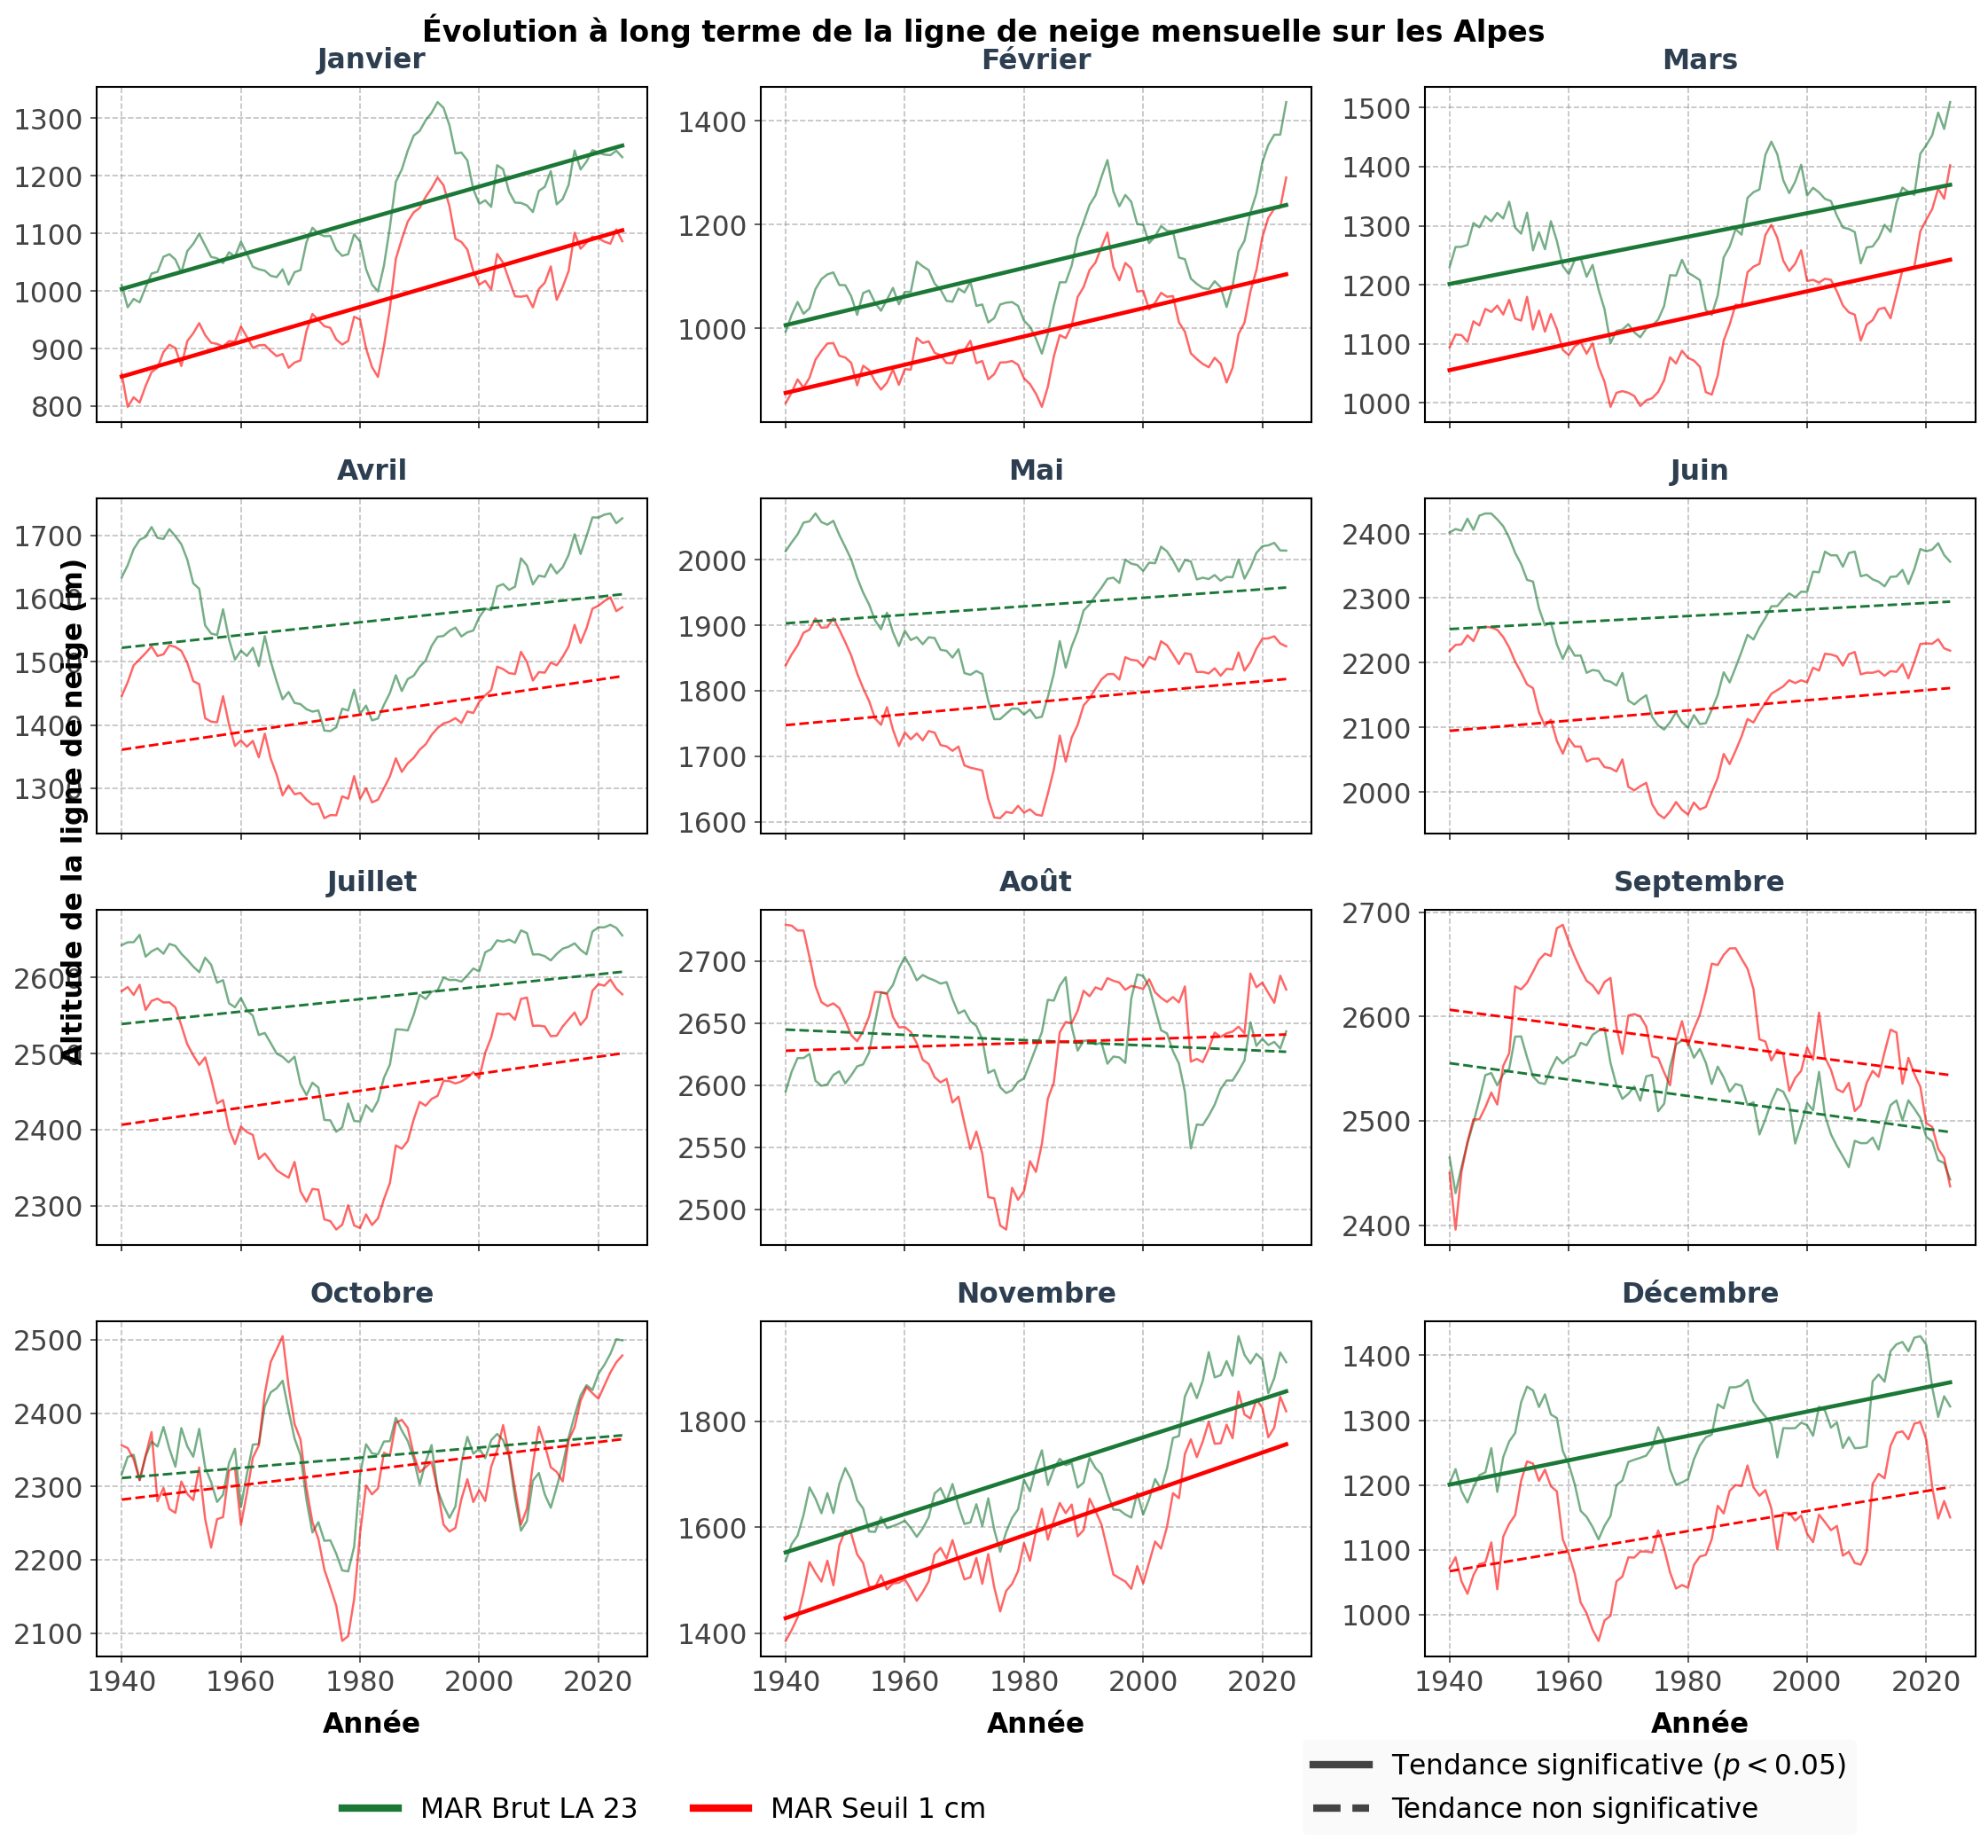

In [24]:
### ici on fait une comparaison MAR brut seuil sur SD et MAR brut avec LA  

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Nimbus Sans', 'DejaVu Sans'],
    'font.size': 15,
    'axes.titlesize': 15,
    'axes.edgecolor': '#888888',   
    'axes.linewidth': 1.0     })
mois_noms = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
             'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

fig, axs = plt.subplots(4, 3, figsize=(16, 15), sharey=False)
axs_flat = axs.flatten()

# Couleurs harmonisées
c_seuil, c_brut = 'red', '#1b7837'

for i in range(months_per_year):
    ax = axs_flat[i]
    ax.set_title(mois_noms[i], color='#2c3e50', weight='bold', pad=10)
    lbl_brut = 'MAR Brut LA 23' if i == 0 else None
    lbl_seuil = 'MAR Seuil 1 cm' if i == 0 else None


    # --- 3. PRODUIT : BRUT ---
    roll_brut = pd.Series(monthly_ln_brut[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(years_unique, roll_brut, color=c_brut, linewidth=1.2, alpha=0.6, zorder=2)
    
    # if i == 0:
    #     roll_std_brut = pd.Series(monthly_ln_brut[:, i]).rolling(window=10, min_periods=3, center=True).std()
    #     ax.fill_between(years_unique, roll_brut - roll_std_brut, roll_brut + roll_std_brut,
    #                   color=c_brut, alpha=0.12, zorder=1, linewidth=0)

    # if i == 0:
    #     ax.scatter(years_unique, monthly_ln_brut[:, i], color=c_brut, alpha=0.4, s=15, zorder=1)
    if not np.isnan(slope_brut[i]):
        sig = pvalue_brut[i] < 0.05
        style_l = 'solid' if sig else 'dashed'
        largeur_l = 2.2 if sig else 1.4
        mask = ~np.isnan(monthly_ln_brut[:, i])
        x_reg = np.where(mask)[0]
        intercept_local = np.nanmean(monthly_ln_brut[:, i]) - slope_brut[i] * np.mean(x_reg)
        ax.plot(years_unique[mask], intercept_local + slope_brut[i] * x_reg, 
                color=c_brut, linestyle=style_l, linewidth=largeur_l, zorder=4, label=lbl_brut)

    roll_seuil = pd.Series(monthly_ln_seuil[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(years_unique, roll_seuil, color=c_seuil, linewidth=1.2, alpha=0.6, zorder=2)
    
    if not np.isnan(slope_seuil[i]):
        sig = pvalue_seuil[i] < 0.05
        style_l = 'solid' if sig else 'dashed'
        largeur_l = 2.2 if sig else 1.4
        mask = ~np.isnan(monthly_ln_seuil[:, i])
        x_reg = np.where(mask)[0]
        intercept_local = np.nanmean(monthly_ln_seuil[:, i]) - slope_seuil[i] * np.mean(x_reg)
        ax.plot(years_unique[mask], intercept_local + slope_seuil[i] * x_reg, 
                color=c_seuil, linestyle=style_l, linewidth=largeur_l, zorder=4, label=lbl_seuil)
        


    ax.yaxis.set_tick_params(labelleft=True, labelsize=15, colors='#222222')  # au lieu de #444444
    ax.xaxis.set_tick_params(labelbottom=True, labelsize=15, colors='#222222', rotation=0)


    # --- Configuration des Axes ---
    ax.grid(True, linestyle='--', alpha=0.6, color='#999999')
    
    # 1. On force l'affichage des altitudes (Y) sur TOUS les graphiques
    ax.yaxis.set_tick_params(labelleft=True, labelsize=15, colors='#444444')
    
    # 2. Gestion de la ligne du bas pour l'axe X (Indices 9, 10, 11 -> Oct, Nov, Déc)
    if i >= 9:
        ax.xaxis.set_tick_params(labelbottom=True, labelsize=15, colors='#444444', rotation=0)
    else:
        ax.xaxis.set_tick_params(labelbottom=False)

    # Nettoyage des bordures
    # Configuration d'un cadre noir complet sur les 4 côtés
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)      
        ax.spines[spine].set_color('black')     
        ax.spines[spine].set_linewidth(1.0)    

# Label de l'axe X pour les trois graphiques du bas
for ax in axs_flat[9:12]:
    ax.set_xlabel('Année', fontsize=15, fontweight='bold', labelpad=8)

leg1 =fig.legend(loc='lower center', bbox_to_anchor=(0.35, 0.01), ncol=3, frameon=False, fontsize=15)

legend_elements = [
    Line2D([0], [0], color='#444444', linestyle='-', linewidth=2, label='Tendance significative ($p < 0.05$)'),
    Line2D([0], [0], color='#444444', linestyle='--', linewidth=1.4, label='Tendance non significative')
]
leg2 = fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.78, 0.01), ncol=1, frameon=True, facecolor='#f9f9f9', edgecolor='none', fontsize=15)
for line in leg1.get_lines():
    line.set_linewidth(4.0)
for line in leg2.get_lines():
    line.set_linewidth(4.0)
# Titres globaux
fig.text(0.073, 0.53, 'Altitude de la ligne de neige (m)', va='center', ha='center', rotation='vertical', fontsize=15, weight='bold')
plt.suptitle('Évolution à long terme de la ligne de neige mensuelle sur les Alpes', size=16, weight='bold', y=0.93)
plt.savefig('/home/mougina/mes_analyses_neige/comparaison_corrections_ligne_neige_bruts_100points.png', dpi=200, bbox_inches='tight')
plt.tight_layout(rect=[0.03, 0.05, 0.98, 0.96])
plt.show()

### on regarde mainteant sur les 45 derneries la ou il semble que la mante soit largemetn plus grande (on recalcule donc les tendances) 

In [32]:
## tableau sur la periode post 1980

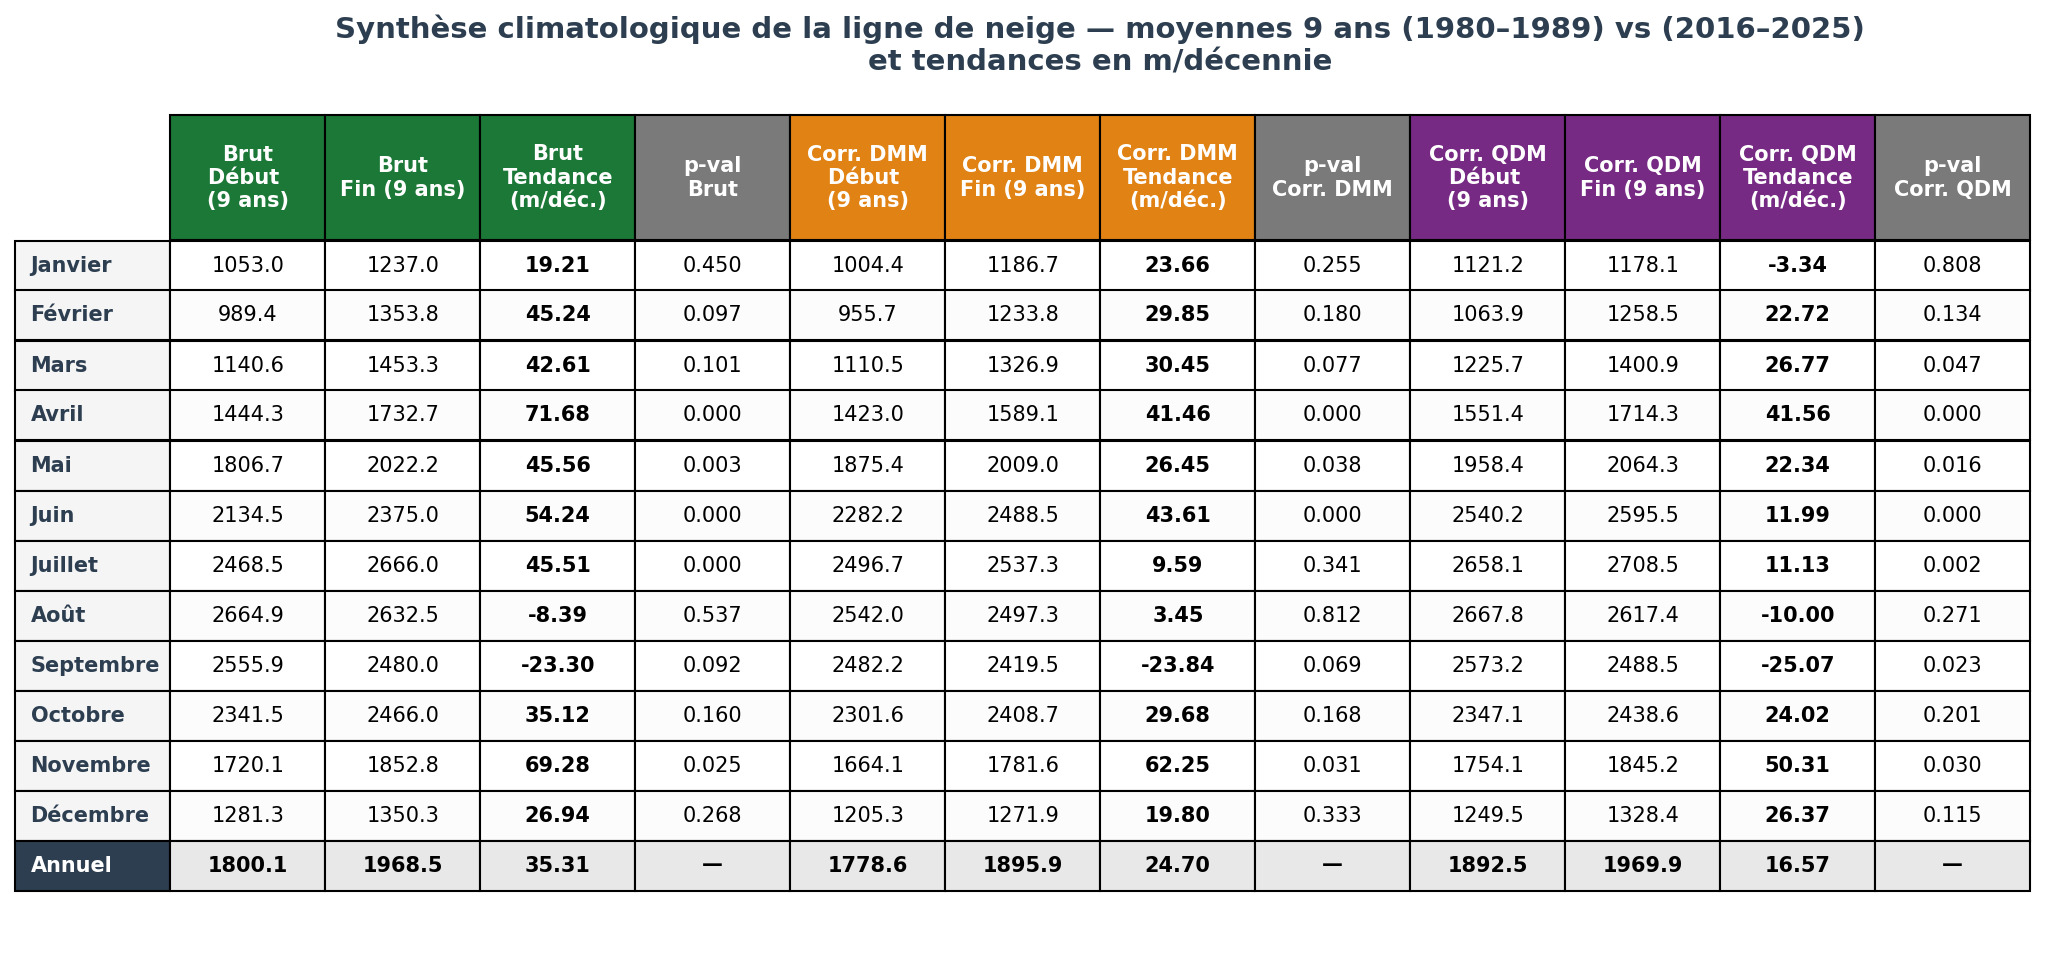

In [27]:
annee_debut = 1980
annee_fin   = 2025  
n_fenetre = (annee_fin - annee_debut) // 5  # ex: 45 // 5 ≈ 9 ans
mask_debut = (years_unique >= annee_debut) & (years_unique < annee_debut + n_fenetre)
mask_fin   = (years_unique >= annee_fin - n_fenetre) & (years_unique < annee_fin)

debut_brut = np.nanmean(monthly_ln_brut[mask_debut, :], axis=0)
fin_brut   = np.nanmean(monthly_ln_brut[mask_fin, :], axis=0)

debut_corr = np.nanmean(monthly_ln_corr[mask_debut, :], axis=0)
fin_corr   = np.nanmean(monthly_ln_corr[mask_fin, :], axis=0) ### il faut recalculer les tendances

debut_qdm  = np.nanmean(monthly_ln_qdm[mask_debut, :], axis=0)
fin_qdm    = np.nanmean(monthly_ln_qdm[mask_fin, :], axis=0)

# --- Nouveau : recalcul des tendances SUR LA PERIODE annee_debut -> annee_fin ---
mask_periode = (years_unique >= annee_debut) & (years_unique < annee_fin)
years_periode = years_unique[mask_periode]

def calcul_tendance_periode(monthly_data, mask_periode, years_periode):
    slope = np.full(months_per_year, np.nan)
    pval  = np.full(months_per_year, np.nan)
    data_periode = monthly_data[mask_periode, :]
    for imonth in range(months_per_year):
        vals = data_periode[:, imonth]
        m = ~np.isnan(vals)
        if m.sum() > 10:  # même seuil que tes calculs originaux
            reg = stats.linregress(years_periode[m], vals[m])
            slope[imonth] = reg.slope
            pval[imonth]  = reg.pvalue
    return slope, pval

slope_brut_p, pvalue_brut_p = calcul_tendance_periode(monthly_ln_brut, mask_periode, years_periode)
slope_corr_p, pvalue_corr_p = calcul_tendance_periode(monthly_ln_corr, mask_periode, years_periode)
slope_qdm_p,  pvalue_qdm_p  = calcul_tendance_periode(monthly_ln_qdm,  mask_periode, years_periode)

tendance_brut = slope_brut_p * 10
tendance_corr = slope_corr_p * 10
tendance_qdm  = slope_qdm_p * 10

pvalue_brut = pvalue_brut_p
pvalue_corr = pvalue_corr_p
pvalue_qdm  = pvalue_qdm_p

# ... (le reste du code, construction de df_visuel etc., ne change pas) 
df_visuel = pd.DataFrame({
    'Brut\nDébut \n(9 ans)':      np.round(debut_brut, 1),
    'Brut\nFin (9 ans)':        np.round(fin_brut, 1),
    'Brut\nTendance\n(m/déc.)':  np.round(tendance_brut, 2),
    'p-val\nBrut':                np.round(pvalue_brut, 3),

    'Corr. DMM\nDébut \n(9 ans)': np.round(debut_corr, 1),
    'Corr. DMM\nFin (9 ans)':   np.round(fin_corr, 1),
    'Corr. DMM\nTendance\n(m/déc.)': np.round(tendance_corr, 2),
    'p-val\nCorr. DMM':          np.round(pvalue_corr, 3),

    'Corr. QDM\nDébut \n(9 ans)':  np.round(debut_qdm, 1),
    'Corr. QDM\nFin (9 ans)':    np.round(fin_qdm, 1),
    'Corr. QDM\nTendance\n(m/déc.)': np.round(tendance_qdm, 2),
    'p-val\nCorr. QDM':           np.round(pvalue_qdm, 3),
}, index=mois_noms)

cols_pval = [c for c in df_visuel.columns if 'p-val' in c]
cols_val  = [c for c in df_visuel.columns if c not in cols_pval]

ligne_annuelle = pd.Series(index=df_visuel.columns, dtype=float)
ligne_annuelle[cols_val] = df_visuel[cols_val].mean(axis=0)
df_visuel.loc['Annuel'] = ligne_annuelle
df_visuel.loc['Annuel', cols_pval] = np.nan  


df_affiche = df_visuel.copy()
for c in cols_pval:
    df_affiche[c] = df_affiche[c].apply(lambda v: '—' if pd.isna(v) else f"{v:.3f}")
for c in cols_val:
    df_affiche[c] = df_affiche[c].apply(lambda v: f"{v:.2f}" if 'Tendance' in c else f"{v:.1f}")


fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')

table_png = ax.table(
    cellText=df_affiche.values,
    rowLabels=df_affiche.index,
    colLabels=df_affiche.columns,
    cellLoc='center',
    loc='center'
)

table_png.auto_set_font_size(False)
table_png.set_fontsize(10)
table_png.scale(1.0, 2.0)

couleur_brut  = '#1b7837'  
couleur_corr  = '#e08214' 
couleur_qdm   = '#762a83'  
couleur_pval  = '#7a7a7a'  
for (row, col), cell in table_png.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        if col in [0, 1, 2]:
            cell.set_facecolor(couleur_brut)
        elif col == 3:
            cell.set_facecolor(couleur_pval)
        elif col in [4, 5, 6]:
            cell.set_facecolor(couleur_corr)
        elif col == 7:
            cell.set_facecolor(couleur_pval)
        elif col in [8, 9, 10]:
            cell.set_facecolor(couleur_qdm)
        elif col == 11:
            cell.set_facecolor(couleur_pval)
        cell.set_height(cell.get_height() * 2.5)
    elif col == -1:
        is_annuel = df_affiche.index[row - 1] == 'Annuel'
        cell.set_text_props(weight='bold', color='#2c3e50' if not is_annuel else 'white')
        cell.set_facecolor('#f5f5f5' if not is_annuel else '#2c3e50')

    else:
        is_annuel = df_affiche.index[row - 1] == 'Annuel'
        if is_annuel:
            cell.set_facecolor('#e8e8e8')
            cell.set_text_props(weight='bold')
        else:
            cell.set_facecolor('#fcfcfc' if row % 2 == 0 else '#ffffff')

        if col in [2, 6, 10]:
            cell.set_text_props(weight='bold')

plt.title(
    f"Synthèse climatologique de la ligne de neige — moyennes 9 ans "
    f"({annee_debut}–{annee_debut+9}) vs ({annee_fin-9}–{annee_fin})\n"
    f"et tendances en m/décennie",
    fontsize=14, weight='bold', pad=30, color='#2c3e50'
, y = 0.9)

chemin_export = '/home/mougina/mes_analyses_neige/tableau_complet_ligne_neige_100points_1980-2025.png'
plt.savefig(chemin_export, dpi=300, bbox_inches='tight')
plt.show()

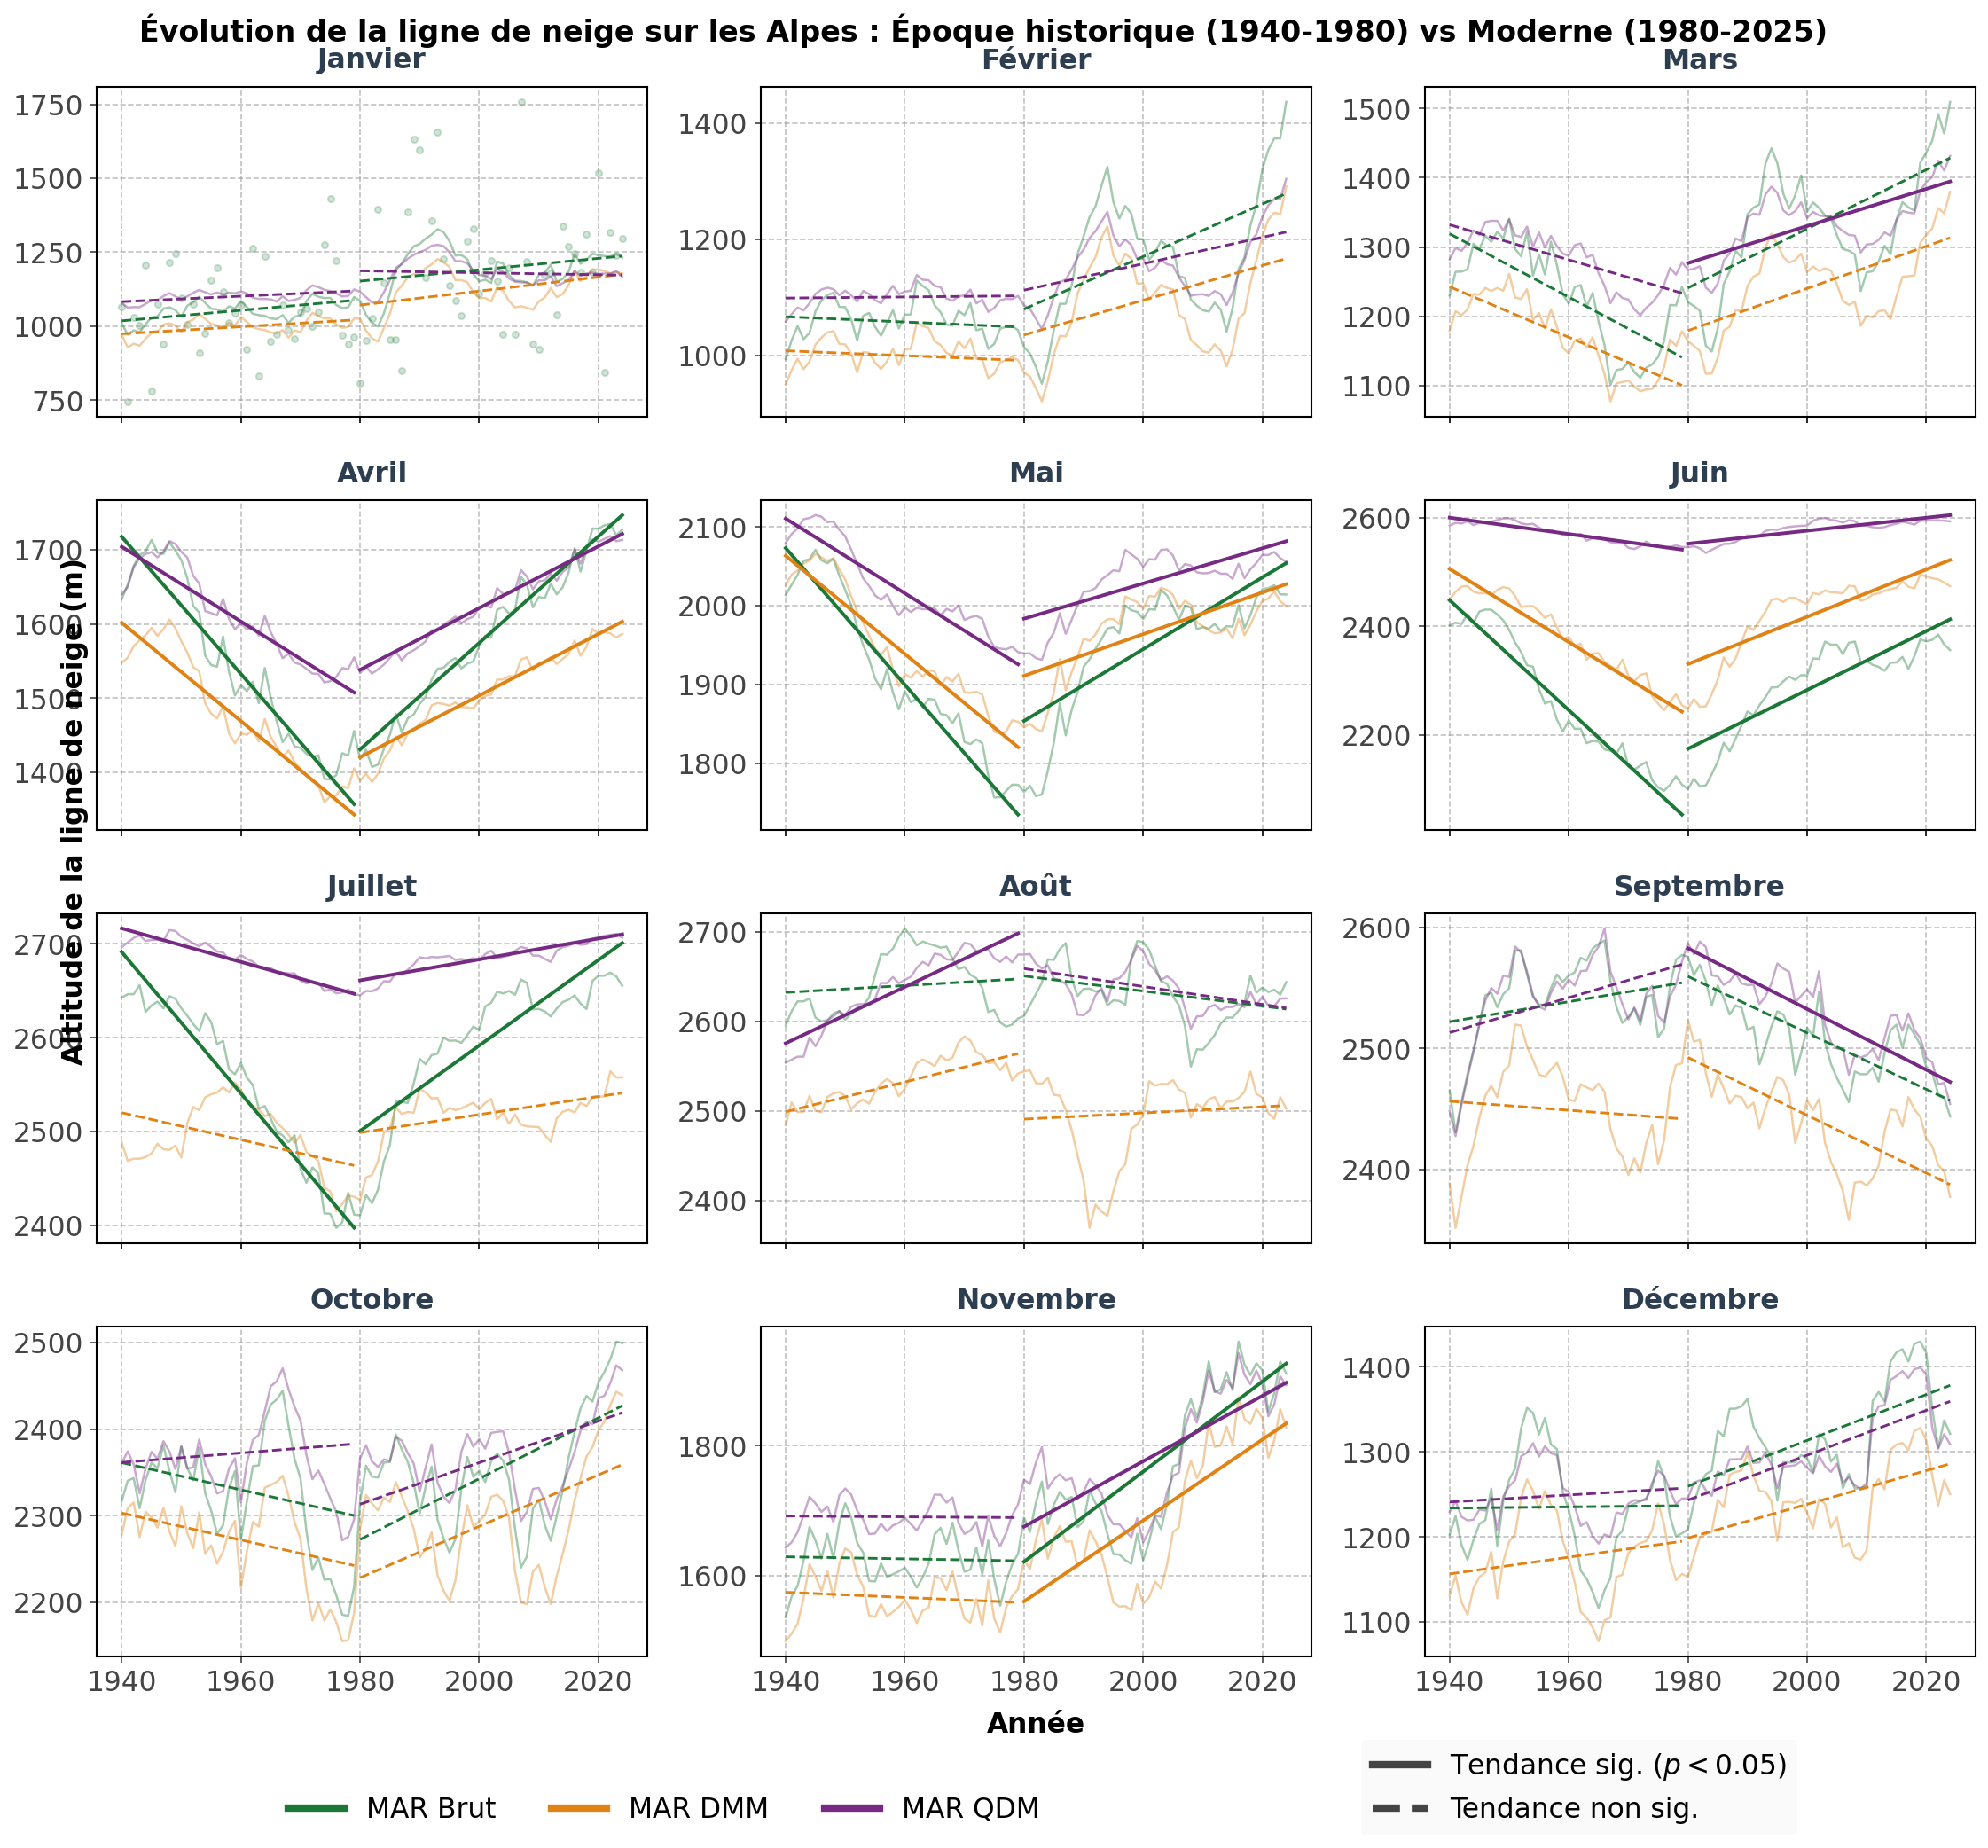

In [45]:

annee_debut_p1, annee_fin_p1 = 1940, 1980
annee_debut_p2, annee_fin_p2 = 1980, 2026

mask_p1 = (years_unique >= annee_debut_p1) & (years_unique < annee_fin_p1)
mask_p2 = (years_unique >= annee_debut_p2) & (years_unique < annee_fin_p2)

years_p1 = years_unique[mask_p1]
years_p2 = years_unique[mask_p2]

slope_brut_p1, pval_brut_p1 = calcul_tendance_periode(monthly_ln_brut, mask_p1, years_p1)
slope_brut_p2, pval_brut_p2 = calcul_tendance_periode(monthly_ln_brut, mask_p2, years_p2)

slope_corr_p1, pval_corr_p1 = calcul_tendance_periode(monthly_ln_corr, mask_p1, years_p1)
slope_corr_p2, pval_corr_p2 = calcul_tendance_periode(monthly_ln_corr, mask_p2, years_p2)

slope_qdm_p1,  pval_qdm_p1  = calcul_tendance_periode(monthly_ln_qdm,  mask_p1, years_p1)
slope_qdm_p2,  pval_qdm_p2  = calcul_tendance_periode(monthly_ln_qdm,  mask_p2, years_p2)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Nimbus Sans', 'DejaVu Sans'],
    'font.size': 15,
    'axes.titlesize': 15,
    'axes.edgecolor': '#888888',   
    'axes.linewidth': 1.0
})

fig, axs = plt.subplots(4, 3, figsize=(16, 15), sharey=False)
axs_flat = axs.flatten()

c_qdm, c_corr, c_brut = '#762a83', '#e08214', '#1b7837'
mois_noms = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
             'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

def tracer_droite_tendance(ax, years, data, slope, pvalue, color, label=None):
    """Trace proprement une droite de régression sur la période temporelle de l'axe X"""
    mask = ~np.isnan(data) & ~np.isnan(years)
    if mask.sum() > 2 and not np.isnan(slope):
        sig = pvalue < 0.05
        style_l = 'solid' if sig else 'dashed'
        largeur_l = 1.9 if sig else 1.4
        
        intercept = np.nanmean(data) - slope * np.nanmean(years[mask])
        
        ax.plot(years[mask], intercept + slope * years[mask], 
                color=color, linestyle=style_l, linewidth=largeur_l, zorder=4, label=label)

for i in range(12):
    ax = axs_flat[i]
    ax.set_title(mois_noms[i], color='#2c3e50', weight='bold', pad=10)
    
    lbl_brut = 'MAR Brut' if i == 0 else None
    lbl_corr = 'MAR DMM' if i == 0 else None
    lbl_qdm  = 'MAR QDM' if i == 0 else None

    # --- Courbes d'évolution (moyenne glissante 10 ans sur l'ensemble de la série) ---
    roll_brut = pd.Series(monthly_ln_brut[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    roll_corr = pd.Series(monthly_ln_corr[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    roll_qdm  = pd.Series(monthly_ln_qdm[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    
    ax.plot(years_unique, roll_brut, color=c_brut, linewidth=1.2, alpha=0.4, zorder=2)
    ax.plot(years_unique, roll_corr, color=c_corr, linewidth=1.2, alpha=0.4, zorder=2)
    ax.plot(years_unique, roll_qdm,  color=c_qdm,  linewidth=1.2, alpha=0.4, zorder=2)
    
    if i in [0]:
        ax.scatter(years_unique, monthly_ln_brut[:, i], color=c_brut, alpha=0.2, s=12, zorder=1)

    tracer_droite_tendance(ax, years_unique[mask_p1], monthly_ln_brut[mask_p1, i], slope_brut_p1[i], pval_brut_p1[i], c_brut, label=lbl_brut)
    tracer_droite_tendance(ax, years_unique[mask_p1], monthly_ln_corr[mask_p1, i], slope_corr_p1[i], pval_corr_p1[i], c_corr, label=lbl_corr)
    tracer_droite_tendance(ax, years_unique[mask_p1], monthly_ln_qdm[mask_p1, i], slope_qdm_p1[i], pval_qdm_p1[i], c_qdm, label=lbl_qdm)

    tracer_droite_tendance(ax, years_unique[mask_p2], monthly_ln_brut[mask_p2, i], slope_brut_p2[i], pval_brut_p2[i], c_brut)
    tracer_droite_tendance(ax, years_unique[mask_p2], monthly_ln_corr[mask_p2, i], slope_corr_p2[i], pval_corr_p2[i], c_corr)
    tracer_droite_tendance(ax, years_unique[mask_p2], monthly_ln_qdm[mask_p2, i], slope_qdm_p2[i], pval_qdm_p2[i], c_qdm)


    ax.grid(True, linestyle='--', alpha=0.6, color='#999999')
    
    # 1. On force l'affichage des altitudes (Y) sur TOUS les graphiques
    ax.yaxis.set_tick_params(labelleft=True, labelsize=15, colors='#444444')
    if i >= 9:
        ax.xaxis.set_tick_params(labelbottom=True, labelsize=15, colors='#444444', rotation=0)
    else:
        ax.xaxis.set_tick_params(labelbottom=False)

    # Nettoyage des bordures
    # Configuration d'un cadre noir complet sur les 4 côtés
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)      
        ax.spines[spine].set_color('black')     
        ax.spines[spine].set_linewidth(1.0)   

# Axe X légendes pour le bas
for ax in axs_flat[10:11]:
    ax.set_xlabel('Année', fontsize=15, fontweight='bold', labelpad=8)

# --- Légendes explicatives ---
leg1 = fig.legend(loc='lower center', bbox_to_anchor=(0.35, 0.01), ncol=3, frameon=False, fontsize=15)
legend_elements = [
    Line2D([0], [0], color='#444444', linestyle='-', linewidth=2, label='Tendance sig. ($p < 0.05$)'),
    Line2D([0], [0], color='#444444', linestyle='--', linewidth=1.4, label='Tendance non sig.')
]
leg2 = fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.78, 0.01), ncol=1, frameon=True, facecolor='#f9f9f9', edgecolor='none', fontsize=15)

for line in leg2.get_lines():  line.set_linewidth(4.0)
for line in leg1.get_lines(): 
    line.set_linestyle('-')
    line.set_linewidth(4.0)

fig.text(0.073, 0.53, 'Altitude de la ligne de neige (m)', va='center', ha='center', rotation='vertical', fontsize=15, weight='bold')
plt.suptitle('Évolution de la ligne de neige sur les Alpes : Époque historique (1940-1980) vs Moderne (1980-2025)', size=16, weight='bold', y=0.93)
plt.savefig('/home/mougina/mes_analyses_neige/comparaison_corrections_rupture_1980_100points.png', dpi=200, bbox_inches='tight')
plt.tight_layout(rect=[0.03, 0.05, 0.98, 0.96])
plt.show()
